# Sleep Profiler EEG macro- and micro-architecture and spectral analysis project updates 

Python packages (dependencies used)
- MNE
- YASA (Yet Another Sleep Algorithm)

Together, these two libraries seem to be the only packages I need to handle EEG analysis. There are a few others including SleepEEGpy (which lumps these packages + others together under one roof) but I haven't found the need for more. YASA and MNE are pretty robust and handle different types of continuous data so it's taking some time to read their documentation to learn all the functions available/relevant for this EEG data project. 

MNE is mainly used for uploading the EEG.edf and hypnogram.csv data while YASA (which is built on top of MNE) is used for artifact removal and the analysis methods I'm looking for. 

In [89]:
## load dependencies
## Not all of these are necessarily required for EEG analysis, (sns, plt) but I like to load a set of standard Python libraries just in case I'll end up using them later on and don't want to import packages in seemingly random places.
import pandas as pd
import numpy as np
import mne
import yasa
# import sleepeegpy
from matplotlib import pyplot as plt
import seaborn as sns
import os

## Import EEG.edf file(s)

In [90]:
## Establish where EEG files are stored for retrieval
file_path = []

In [91]:
## import EEG.edf file and hypnogram (csv)
raw = mne.io.read_raw_edf('KellyS_Test.edf',
                          infer_types= True, ## tries to automatically understand what channel is which based on name
                           preload=True) 

## preload (default = False) preloads data into memory for faster indexing (requires large amount of memory) and may not be required but is recommended in later method below.
## mne.io.raw documentation recommends preload = True, otherwise edge artifacts appear when slices of the dignal are requested. 

Extracting EDF parameters from /Users/thomasgooding/Desktop/Git_mats/Portfolio/Data_Projects/Rutgers Research/Sleep_Profiler_SOP/KellyS_Test.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6918399  =      0.000 ... 27024.996 secs...


In [92]:
raw = mne.io.read_raw_edf('KellyS_Test.edf',
                          eog = ['EEG2', 'EEG3'],
                          infer_types= True, ## tries to automatically understand what channel is which based on name
                           preload=True) 

Extracting EDF parameters from /Users/thomasgooding/Desktop/Git_mats/Portfolio/Data_Projects/Rutgers Research/Sleep_Profiler_SOP/KellyS_Test.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6918399  =      0.000 ... 27024.996 secs...


In [93]:
print(raw)

<RawEDF | KellyS_Test.edf, 26 x 6918400 (27025.0 s), ~1.34 GB, data loaded>


## Roadblock #1 Mapping SleepProfiler EEG.edf data to appropriate channels


**Roadblock Explained:** If you look at the next cell's output, there are 26 channels in the SleepProfiler headband (listed in the following code block). There are 4 EEG channels, 3 'tilt' channels (XYZ accelerometer), 2 infrared channels (IRED, RED), a snore channel (microphone), and then 16 T_number channels. 

The documentation I'm following is mostly based on PSG + EEG cap-based data. I'm aware of the physiological signals that the SleepProfiler headband is capturing based on the data reports and SleepProfiler editor tool but it's not simply a 1:1 analysis plan for the type of EEG data we've captured vs. cap-based EEG. 

I don't think the tilt channels are relevant to anything I need but I'm not sure. The EEG channels are the important channels to analyze, but I'm not sure of the nuance among the four channels—also, there are only three electrodes to my knowledge for data capture so I'm not sure how three electrodes results in four EEG channels of data. (though I'm still learning about EEG and waveform data in general.)

Any insights here would be welcome.

**Problem-solving Roadblock #1**:

raw.info opens up a lot of information about the device/file itself. There are many methods and attributes that can be called. Some are descriptive (e.g., raw.info['device_info]) whereby you can provide string-based information such as context of the specific device used for data measurement.

Some that might help are called in the next several blocks of code. If nothing else, these will also allow more specificity in the data analysis pre-processing stage, like specifying what channels from the device correspond with which datatype (e.g., XYZ Channels are EEG but these are EOG and this is HR.)

In [94]:
raw.info ## this is considered an attribute (vs. a method)

# attributes = static properties of Python objects- things that are pre-computed and stored as part of the object's representation in memory. Attributes are accessed with the . operator and don't require parentheses after the attribute name

Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"24 EEG, 2 EOG"
Bad channels,None
EOG channels,"EEG2, EEG3"
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [95]:
raw.info['chs'] ## a list of channel information dictionaires, one per channel. See MNE notes for more info.

chs_info_df = pd.DataFrame(raw.info['chs'])

chs_info_df

,cal,logno,scanno,range,unit_mul,ch_name,unit,coord_frame,coil_type,kind,loc
0,1.0,1,1,1.0,0,EEG1,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
1,1.0,2,2,1.0,0,EEG2,107,4,0,202,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
2,1.0,3,3,1.0,0,EEG3,107,4,0,202,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
3,1.0,4,4,1.0,0,EEG4,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
4,1.0,5,5,1.0,0,Tilt1,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
5,1.0,6,6,1.0,0,Tilt2,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
6,1.0,7,7,1.0,0,Tilt3,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
7,1.0,8,8,1.0,0,IRED,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
8,1.0,9,9,1.0,0,RED,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
9,1.0,10,10,1.0,0,Snore,107,4,1,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."


In [96]:
raw.info['description'] = 'This is a test project to set up EEG analysis' ## can give string description of the recording file.

raw.info['loc'] can be used to establish channel location information. The first three elements [0:3] always store the nominal channel position. The remaining 9 elements store different information based on the channel type: 
- **EEG**: Elements [3:6] contain reference channel position
- **Eyetrack**: Element [3] contains information about which eye was tracked (-1 for left, 1 for right), and element [4] contains information about the axis of coordinate data (-1 for x-coordinate data, 1 for y-coordinate data).
- **Dipole:** Elements [3:6] contain dipole orientation information.
- **logno:** logical channel number, conventions in the usage of this number may vary.
- **range**: the hardware-oriented part of the calibraiton factor. should only be applied to continuous raw data. Used in product with [cal] to scale data read from disk.
- **events**: can include channels (list of channels) list of int.
- **hpi_meas**: things like sfreq (sample rate), nchan, first_samp, last_samp, hpi_coils (more under this last one.)
  - **Similar attributes might have relevant info I can find from Sleep Profiler's own validation studies or similar publications (e.g., operation manual).**
- **subject_info** dict. This includes first_ last_name, dob, sex, height, weight, handedness...Could potentially 'fit' our data better in future against the same dataset that YASA used...AI/ML. The Rutgers data is the testing dataset and the



**Not relevant but also included:**
- **MEG:** Remaining 9 elements [3:], contain the EX, EY, and EZ normal triplets (columns) of the coil rotation/orientation matrix.


In [97]:
raw.info['hpi_meas']

[]

In [98]:
## get channel names, another attribute
raw.ch_names

['EEG1',
 'EEG2',
 'EEG3',
 'EEG4',
 'Tilt1',
 'Tilt2',
 'Tilt3',
 'IRED',
 'RED',
 'Snore',
 'TC0',
 'TC1',
 'TC2',
 'TC3',
 'TC4',
 'TC5',
 'TC6',
 'TC7',
 'TC8',
 'TC9',
 'TC10',
 'TC11',
 'TC12',
 'TC13',
 'TC14',
 'TC15']

In [99]:
## drop channels TC0 to TC15. These are internal to the X8 device and not phyisological signal (may learn otherwise later)
raw.drop_channels([f'TC{i}' for i in range(16)]) # this is considered a Python method ()

## methods are specialized functions attached to an object. Usually, these require additional user input (kwargs) and/or some computation to provide a result. These always have () at the end and additional arguments go inside the ().

Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"8 EEG, 2 EOG"
Bad channels,None
EOG channels,"EEG2, EEG3"
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [100]:
## set channel types for mapping
channel_types = {
    'EEG1':'emg', 'EEG2':'eog', 'EEG3':'eog', 'EEG4':'eeg', 'Tilt1': 'misc', 'Tilt2':'misc',
    'Tilt3':'misc', 'IRED':'bio', 'RED':'bio', 'Snore':'misc'}

raw.set_channel_types(channel_types)
## this works even though the output is a dropdown (note the Good channel types) compared to the previous window

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_65100/1898907110.py:6: RuntimeWarning: The unit for channel(s) Snore, Tilt1, Tilt2, Tilt3 has changed from V to NA.
  raw.set_channel_types(channel_types)


Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"1 EMG, 2 EOG, 1 EEG, 4 misc, 2 BIO"
Bad channels,None
EOG channels,"EEG2, EEG3"
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [101]:
print(raw.get_channel_types())

['emg', 'eog', 'eog', 'eeg', 'misc', 'misc', 'misc', 'bio', 'bio', 'misc']


# Sussing out these EEG Chanels

### Step 1: Quantify how similar/different the 4 EEG channels actually are...

In [102]:
## Isolating EEG channels
channels = ['EEG1', 'EEG2', 'EEG3', 'EEG4']

data = {ch: raw.get_data(picks=ch)[0] * 1e6 for ch in channels}  # µV

## Pairwise correlation matrix
corr_matrix = pd.DataFrame({ch: data[ch] for ch in channels}).corr()
print(corr_matrix.round(3))

       EEG1   EEG2   EEG3   EEG4
EEG1  1.000  0.180  0.131  0.096
EEG2  0.180  1.000  0.585  0.457
EEG3  0.131  0.585  1.000 -0.374
EEG4  0.096  0.457 -0.374  1.000


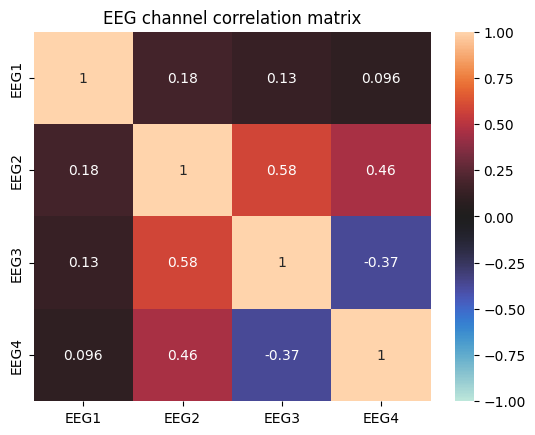

In [103]:
sns.heatmap(data= corr_matrix, vmin=-1, vmax=1, cmap='icefire', annot=True)

plt.title('EEG channel correlation matrix')
plt.show()

**Interpretation:**

EEG1 has weak overall correlation with EEG channels 2 through 4 (range 0.096 to 0.18)
EEG2 has strongest between itself and EEG3 (r= 0.58), and decent with EEG4 (r=0.46).
EEG3 has negative correlation with EEG4 (r=-0.37) and strongest with EEG2 (r= 0.58). 
EEG4 has mixed (+/-) associations with EEG2 (r=0.46) and EEG3 (r=-0.37)

EEG3 would be the channel most strongly associated with the activity of other EEG channels, but the associations of all these between one another aren't "great."

## Step 2: Diagnose EEG1 specifically

In [104]:
raw.info
## Notes:
## Highpass = 0, lowpass = 128 Hz from a sampling frequency of 256 Hz (lowpass set to 1/2 if H-pass is 0, per documentation).

Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"1 EMG, 2 EOG, 1 EEG, 4 misc, 2 BIO"
Bad channels,None
EOG channels,"EEG2, EEG3"
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


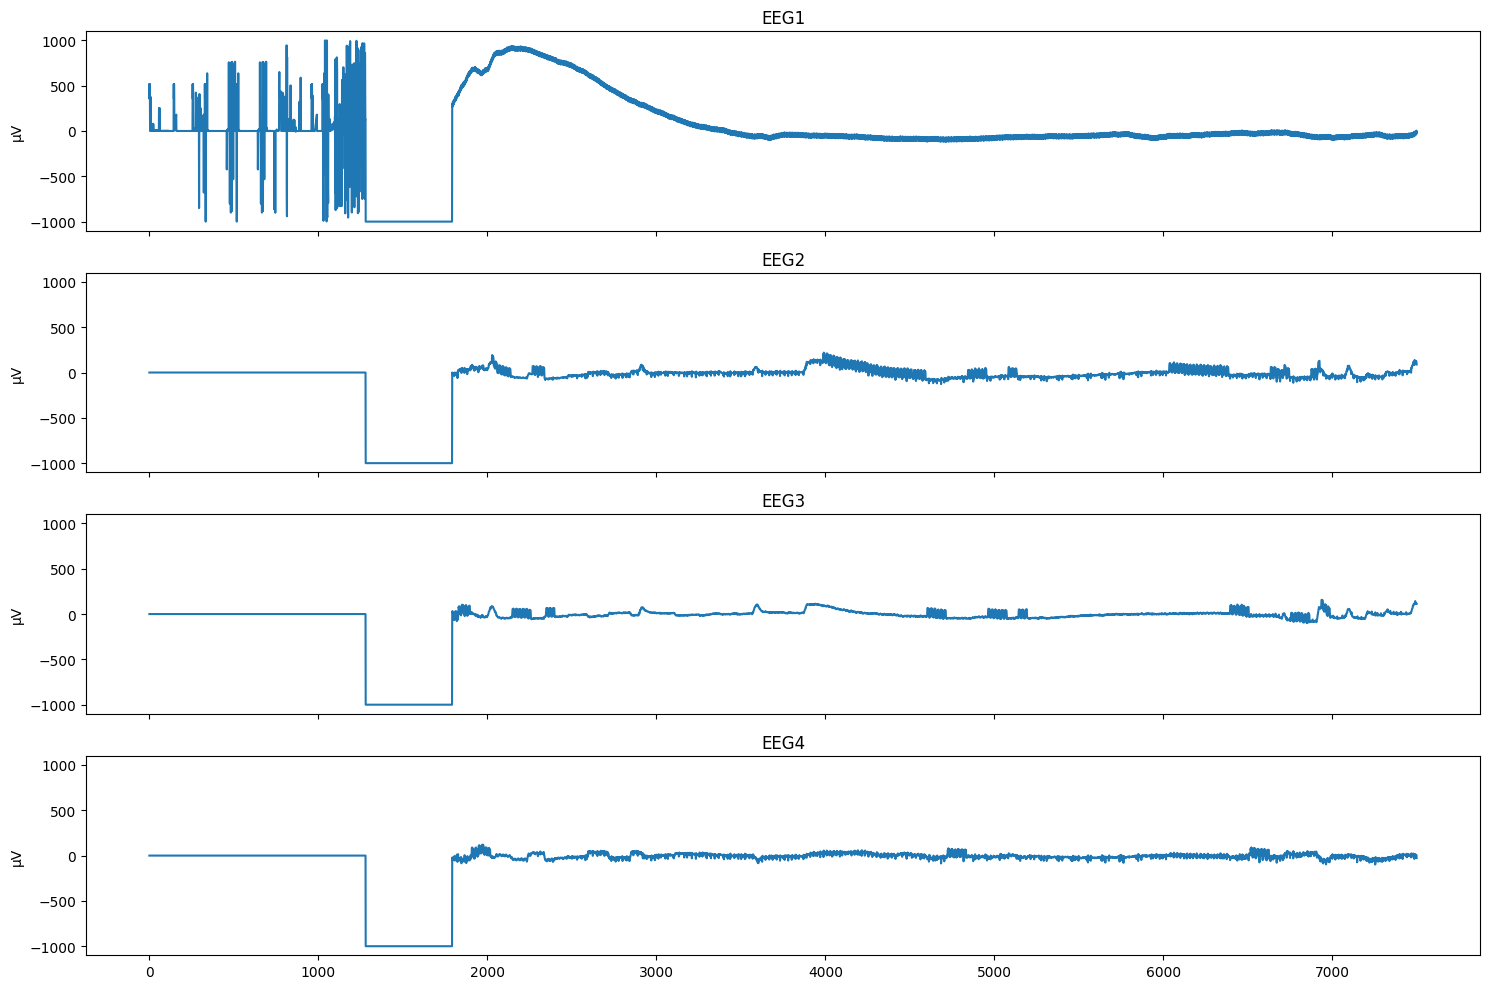

In [105]:
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True, sharey=True)

for i, ch in enumerate(channels):
    axes[i].plot(data[ch][:7500])  # ~30 sec at 250Hz, adjust to your sf
    axes[i].set_title(ch)
    axes[i].set_ylabel("µV")
plt.tight_layout()

plt.show()

In [106]:
for ch in channels:
    print(f"{ch}: std={data[ch].std():.2f}, min={data[ch].min():.2f}, max={data[ch].max():.2f}, "
          f"range={np.ptp(data[ch]):.2f}")

EEG1: std=47.88, min=-1000.00, max=1000.00, range=2000.00
EEG2: std=23.23, min=-1000.00, max=1000.00, range=2000.00
EEG3: std=24.61, min=-1000.00, max=1000.00, range=2000.00
EEG4: std=23.54, min=-1000.00, max=1000.00, range=2000.00


**Interpretation:**

One of these things is not like the other...Channel EEG1 has what appears to be a lot of artifact. However, this could instead be drift. 

In [107]:
import numpy as np

def check_eeg1_drift(raw, threshold_uV=200, window_samples=7500):
    """
    Returns True if EEG1 shows DC drift artifact in the first window
    (defined as mean absolute amplitude exceeding threshold)
    """
    data_eeg1 = raw.get_data(picks='EEG1')[0][:window_samples] * 1e6
    # Exclude the saturation period (values at -1000 µV clipping floor)
    valid = data_eeg1[np.abs(data_eeg1) < 990]
    mean_abs = np.abs(valid).mean()
    return mean_abs > threshold_uV, mean_abs

# Run on each file in your batch before committing to excluding EEG1 universally

In [108]:
check_eeg1_drift(raw)

(False, 168.42596367506644)

In [109]:
def check_eeg1_drift(raw, peak_threshold_uV=300, range_threshold_uV=500, 
                     window_samples=7500):
    """
    Checks for DC drift artifact in EEG1 using peak amplitude and 
    signal range — more sensitive than mean for slow drift artifacts.
    
    Returns: (is_artifact, peak_abs_amplitude, signal_range, mean_abs)
    """
    data_eeg1 = raw.get_data(picks='EEG1')[0][:window_samples] * 1e6
    
    # Exclude saturation clipping floor (-1000 µV)
    valid = data_eeg1[np.abs(data_eeg1) < 990]
    
    peak_abs = np.abs(valid).max()
    signal_range = np.ptp(valid)  # peak-to-trough range
    mean_abs = np.abs(valid).mean()
    
    # Flag if either peak OR range exceeds thresholds
    is_artifact = (peak_abs > peak_threshold_uV) or (signal_range > range_threshold_uV)
    
    return {
        "is_artifact": is_artifact,
        "peak_abs_uV": round(peak_abs, 2),
        "signal_range_uV": round(signal_range, 2),
        "mean_abs_uV": round(mean_abs, 2),
    }

# Run on your file
result = check_eeg1_drift(raw)
print(result)

{'is_artifact': True, 'peak_abs_uV': 988.62, 'signal_range_uV': 1944.03, 'mean_abs_uV': 168.43}


In [110]:
# Identify best channel for spindle analysis (highest sigma-band SNR)
from scipy.signal import welch

sf = raw.info['sfreq']
sigma_snr = {}

for ch in ['EEG2', 'EEG3', 'EEG4']:
    d = raw.get_data(picks=ch)[0] * 1e6
    freqs, psd = welch(d, sf, nperseg=int(sf * 4))
    sigma_idx = (freqs >= 12) & (freqs <= 15)
    broad_idx = (freqs >= 1) & (freqs <= 30)
    snr = psd[sigma_idx].mean() / psd[broad_idx].mean()
    sigma_snr[ch] = snr
    print(f"{ch}: sigma SNR = {snr:.4f}")

best_ch = max(sigma_snr, key=sigma_snr.get)
print(f"\nHighest sigma SNR: {best_ch}")

EEG2: sigma SNR = 0.5606
EEG3: sigma SNR = 0.4409
EEG4: sigma SNR = 0.3418

Highest sigma SNR: EEG2


In [111]:
## Testing the chance of whether one of these EEG channels is a 'composite' channel

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
## Downsample slightly for speed — every 10th sample still gives you high temporal resolution
step = 10
X = np.column_stack([data['EEG1'][::step],
                     data['EEG2'][::step],
                     data['EEG3'][::step]])
y = data['EEG4'][::step]

## Fit on first half, predict on second half (avoids overfitting concern)
split = len(y) // 2
reg = LinearRegression().fit(X[:split], y[:split])
y_pred = reg.predict(X[split:])

r2 = r2_score(y[split:], y_pred)
print(f"R² (EEG1–3 predicting EEG4): {r2:.4f}")
print(f"Coefficients: EEG1={reg.coef_[0]:.4f}, EEG2={reg.coef_[1]:.4f}, EEG3={reg.coef_[2]:.4f}")
print(f"Intercept: {reg.intercept_:.4f}")

R² (EEG1–3 predicting EEG4): 0.9490
Coefficients: EEG1=0.0406, EEG2=1.0537, EEG3=-0.9284
Intercept: -0.1678


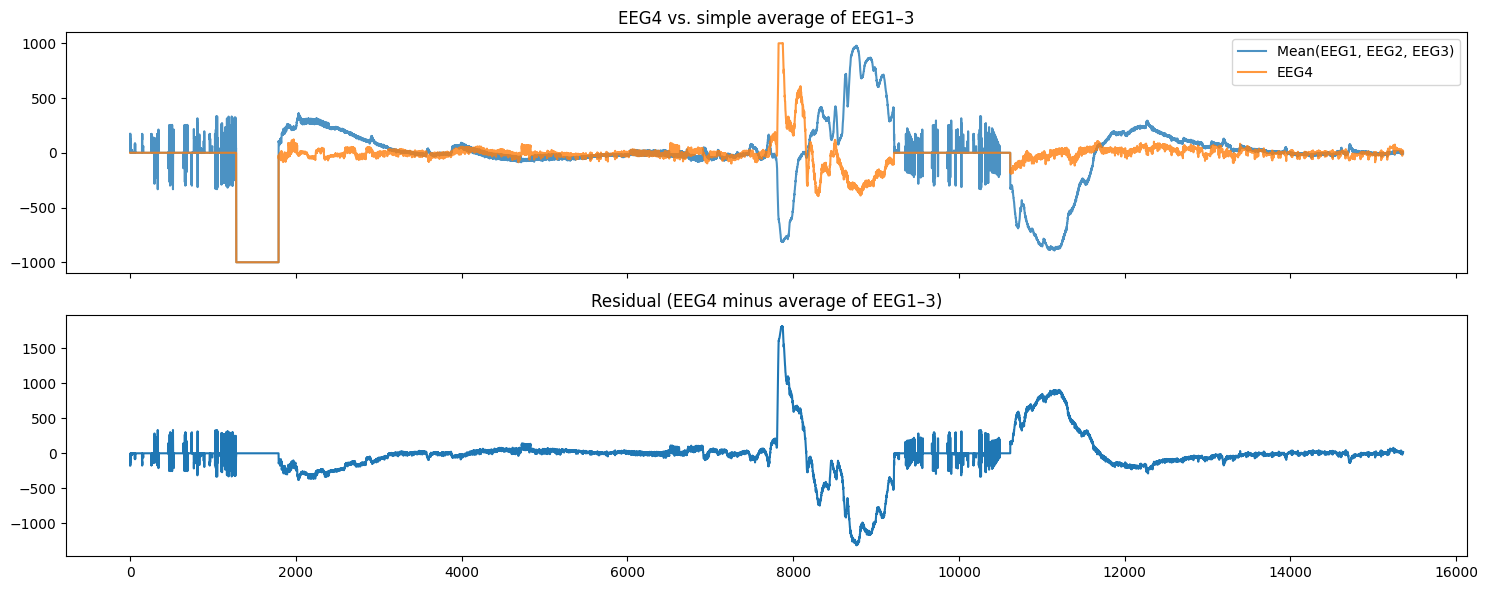

In [112]:
## Compare EEG4 against the simple average of EEG1–3 for a 60-second window
avg_123 = (data['EEG1'] + data['EEG2'] + data['EEG3']) / 3
sf = int(raw.info['sfreq'])
window = slice(0, 60 * sf)

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
axes[0].plot(avg_123[window], label='Mean(EEG1, EEG2, EEG3)', alpha=0.8)
axes[0].plot(data['EEG4'][window], label='EEG4', alpha=0.8)

axes[0].legend()
axes[0].set_title("EEG4 vs. simple average of EEG1–3")
axes[1].plot(data['EEG4'][window] - avg_123[window])
axes[1].set_title("Residual (EEG4 minus average of EEG1–3)")

plt.tight_layout()

plt.show()

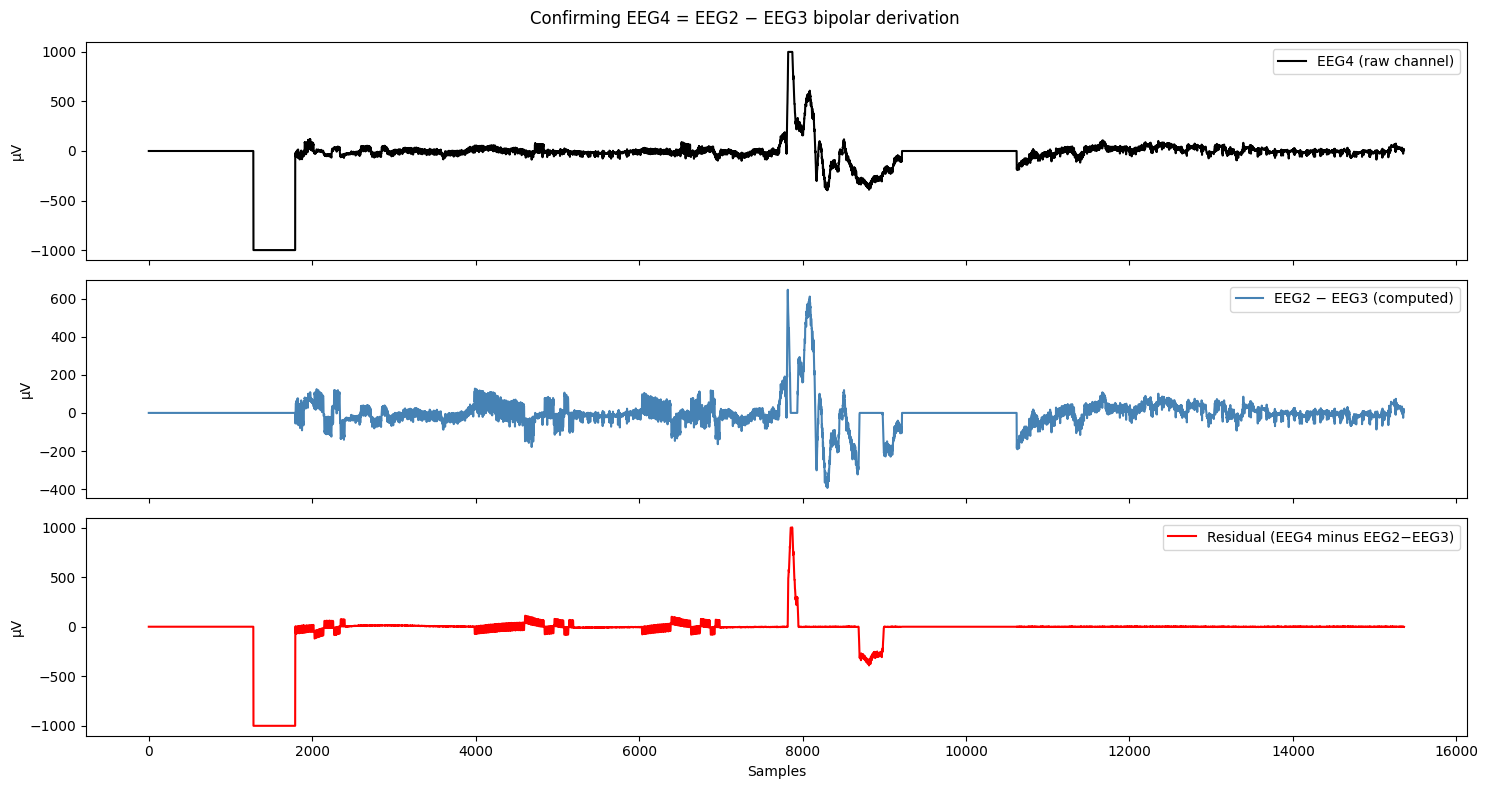

Correlation between EEG4 and (EEG2−EEG3): r = 0.9076


In [113]:
import matplotlib.pyplot as plt

sf = int(raw.info['sfreq'])
window = slice(0, 60 * sf)

eeg2_minus_eeg3 = data['EEG2'] - data['EEG3']

fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)
axes[0].plot(data['EEG4'][window], label='EEG4 (raw channel)', color='black')
axes[0].legend(); axes[0].set_ylabel('µV')

axes[1].plot(eeg2_minus_eeg3[window], label='EEG2 − EEG3 (computed)', color='steelblue')
axes[1].legend(); axes[1].set_ylabel('µV')

axes[2].plot(data['EEG4'][window] - eeg2_minus_eeg3[window], 
             label='Residual (EEG4 minus EEG2−EEG3)', color='red')
axes[2].legend(); axes[2].set_ylabel('µV')
axes[2].set_xlabel('Samples')

plt.suptitle('Confirming EEG4 = EEG2 − EEG3 bipolar derivation')
plt.tight_layout()
plt.show()

r_bipolar = np.corrcoef(data['EEG4'], eeg2_minus_eeg3)[0,1]
print(f"Correlation between EEG4 and (EEG2−EEG3): r = {r_bipolar:.4f}")

In [114]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

channels = ['EEG1', 'EEG2', 'EEG3', 'EEG4']

# Pull all 4 channels into a dict, downsample for speed
step = 10
data_ds = {ch: raw.get_data(picks=ch)[0][::step] * 1e6 for ch in channels}

r2_results = []

for target_ch in channels:
    # Use the other 3 as predictors
    predictor_chs = [ch for ch in channels if ch != target_ch]
    
    X = np.column_stack([data_ds[ch] for ch in predictor_chs])
    y = data_ds[target_ch]
    
    # Fit on first half, test on second half
    split = len(y) // 2
    reg = LinearRegression().fit(X[:split], y[:split])
    y_pred = reg.predict(X[split:])
    r2 = r2_score(y[split:], y_pred)
    
    coef_dict = {f"coef_{predictor_chs[i]}": round(reg.coef_[i], 4) for i in range(len(predictor_chs))}
    
    r2_results.append({
        "target_channel": target_ch,
        "R2_from_other_three": round(r2, 4),
        **coef_dict,
        "intercept": round(reg.intercept_, 4)
    })

r2_df = pd.DataFrame(r2_results)
print(r2_df.to_string(index=False))

target_channel  R2_from_other_three  coef_EEG2  coef_EEG3  coef_EEG4  intercept  coef_EEG1
          EEG1              -0.0059    -0.2388     0.6465     0.4583     0.1592        NaN
          EEG2               0.8862        NaN     0.8125     0.7051     0.0971    -0.0141
          EEG3               0.8779     1.0030        NaN    -0.7670    -0.1474     0.0473
          EEG4               0.9490     1.0537    -0.9284        NaN    -0.1678     0.0406


In [115]:
import pandas as pd

data_full = {ch: raw.get_data(picks=ch)[0] * 1e6 for ch in channels}
corr_df = pd.DataFrame(data_full).corr().round(3)
print(corr_df)

       EEG1   EEG2   EEG3   EEG4
EEG1  1.000  0.180  0.131  0.096
EEG2  0.180  1.000  0.585  0.457
EEG3  0.131  0.585  1.000 -0.374
EEG4  0.096  0.457 -0.374  1.000


In [116]:
# Check if any channel is simply an inverted version of another
for ch in ['EEG1','EEG2','EEG3']:
    r = np.corrcoef(data_full['EEG4'], data_full[ch])[0,1]
    print(f"EEG4 vs {ch}: r = {r:.3f}")

EEG4 vs EEG1: r = 0.096
EEG4 vs EEG2: r = 0.457
EEG4 vs EEG3: r = -0.374


In [117]:
# from mne.preprocessing import ICA
# ica = ICA(n_components=4, random_state=42)
# ica.fit(raw.copy().pick(['EEG1','EEG2','EEG3','EEG4']))
# ica.plot_sources(raw.copy().pick(['EEG1','EEG2','EEG3','EEG4']))

# plt.show()

In [118]:
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots(figsize=(10, 5))
# for ch in channels:
#     psds, freqs = raw.compute_psd(picks=ch).get_data(return_freqs=True)
#     ax.semilogy(freqs, psds[0], label=ch)
# ax.set_xlim(0, 35)
# ax.set_xlabel('Frequency (Hz)')
# ax.set_ylabel('Power (V²/Hz)')
# ax.legend()
# plt.title('PSD comparison across EEG channels')
# plt.show()

In [119]:
epoch_len = int(30 * raw.info['sfreq'])
for ch in channels:
    d = data_full[ch]
    epoch_rms = [np.sqrt(np.mean(d[i:i+epoch_len]**2)) 
                 for i in range(0, len(d)-epoch_len, epoch_len)]
    print(f"{ch}: mean epoch RMS = {np.mean(epoch_rms):.2f} µV, "
          f"std = {np.std(epoch_rms):.2f} µV")

EEG1: mean epoch RMS = 22.77 µV, std = 41.55 µV
EEG2: mean epoch RMS = 15.45 µV, std = 16.58 µV
EEG3: mean epoch RMS = 16.02 µV, std = 18.07 µV
EEG4: mean epoch RMS = 19.03 µV, std = 13.70 µV


In [120]:
from scipy.signal import welch
import pandas as pd

def compute_band_snr(raw, channels, sf):
    """
    Compute delta and sigma band SNR for each channel.
    SNR defined as band power / mean broadband power (1-30 Hz).
    """
    results = []
    for ch in channels:
        d = raw.get_data(picks=ch)[0] * 1e6
        freqs, psd = welch(d, sf, nperseg=int(sf * 4))
        
        delta_idx = (freqs >= 0.5) & (freqs <= 4)
        sigma_idx = (freqs >= 12) & (freqs <= 15)
        broad_idx = (freqs >= 1) & (freqs <= 30)
        
        broad_mean = psd[broad_idx].mean()
        
        results.append({
            "channel": ch,
            "delta_snr": psd[delta_idx].mean() / broad_mean,
            "sigma_snr": psd[sigma_idx].mean() / broad_mean,
        })
    
    return pd.DataFrame(results).sort_values("sigma_snr", ascending=False)

snr_df = compute_band_snr(raw, ['EEG2', 'EEG3', 'EEG4'], raw.info['sfreq'])
print(snr_df)

  channel  delta_snr  sigma_snr
0    EEG2  15.037530   0.560615
1    EEG3  16.296690   0.440851
2    EEG4  13.203805   0.341764


In [121]:
snr_df = compute_band_snr(raw, ['EEG2', 'EEG3', 'EEG4'], raw.info['sfreq'])
print(snr_df.round(4))

  channel  delta_snr  sigma_snr
0    EEG2    15.0375     0.5606
1    EEG3    16.2967     0.4409
2    EEG4    13.2038     0.3418


In [122]:
from scipy.signal import welch
import numpy as np

def compute_nrem_band_snr(raw, hyp, channels):
    """
    Compute delta and sigma SNR during NREM epochs only (N2 + N3),
    which is when spindles and slow waves actually occur.
    """
    sf = raw.info['sfreq']
    epoch_len = int(30 * sf)
    
    # Get NREM epoch indices from hypnogram
    hypno_int = hyp.as_int().to_numpy()
    nrem_epochs = np.where(np.isin(hypno_int, [2, 3]))[0]
    
    results = []
    for ch in channels:
        d = raw.get_data(picks=ch)[0] * 1e6
        
        # Concatenate only NREM epochs
        nrem_signal = np.concatenate([
            d[i * epoch_len:(i + 1) * epoch_len]
            for i in nrem_epochs
            if (i + 1) * epoch_len <= len(d)
        ])
        
        freqs, psd = welch(nrem_signal, sf, nperseg=int(sf * 4))
        
        delta_idx = (freqs >= 0.5) & (freqs <= 4)
        sigma_idx = (freqs >= 12) & (freqs <= 15)
        broad_idx = (freqs >= 1) & (freqs <= 30)
        broad_mean = psd[broad_idx].mean()
        
        results.append({
            "channel": ch,
            "delta_snr_nrem": psd[delta_idx].mean() / broad_mean,
            "sigma_snr_nrem": psd[sigma_idx].mean() / broad_mean,
        })
    
    import pandas as pd
    return pd.DataFrame(results).sort_values("sigma_snr_nrem", ascending=False)

nrem_snr_df = compute_nrem_band_snr(raw, hyp, ['EEG2', 'EEG3', 'EEG4'])
print(nrem_snr_df.round(4))

  channel  delta_snr_nrem  sigma_snr_nrem
0    EEG2         12.3769          0.5933
1    EEG3         13.3784          0.4765
2    EEG4         12.1054          0.3502


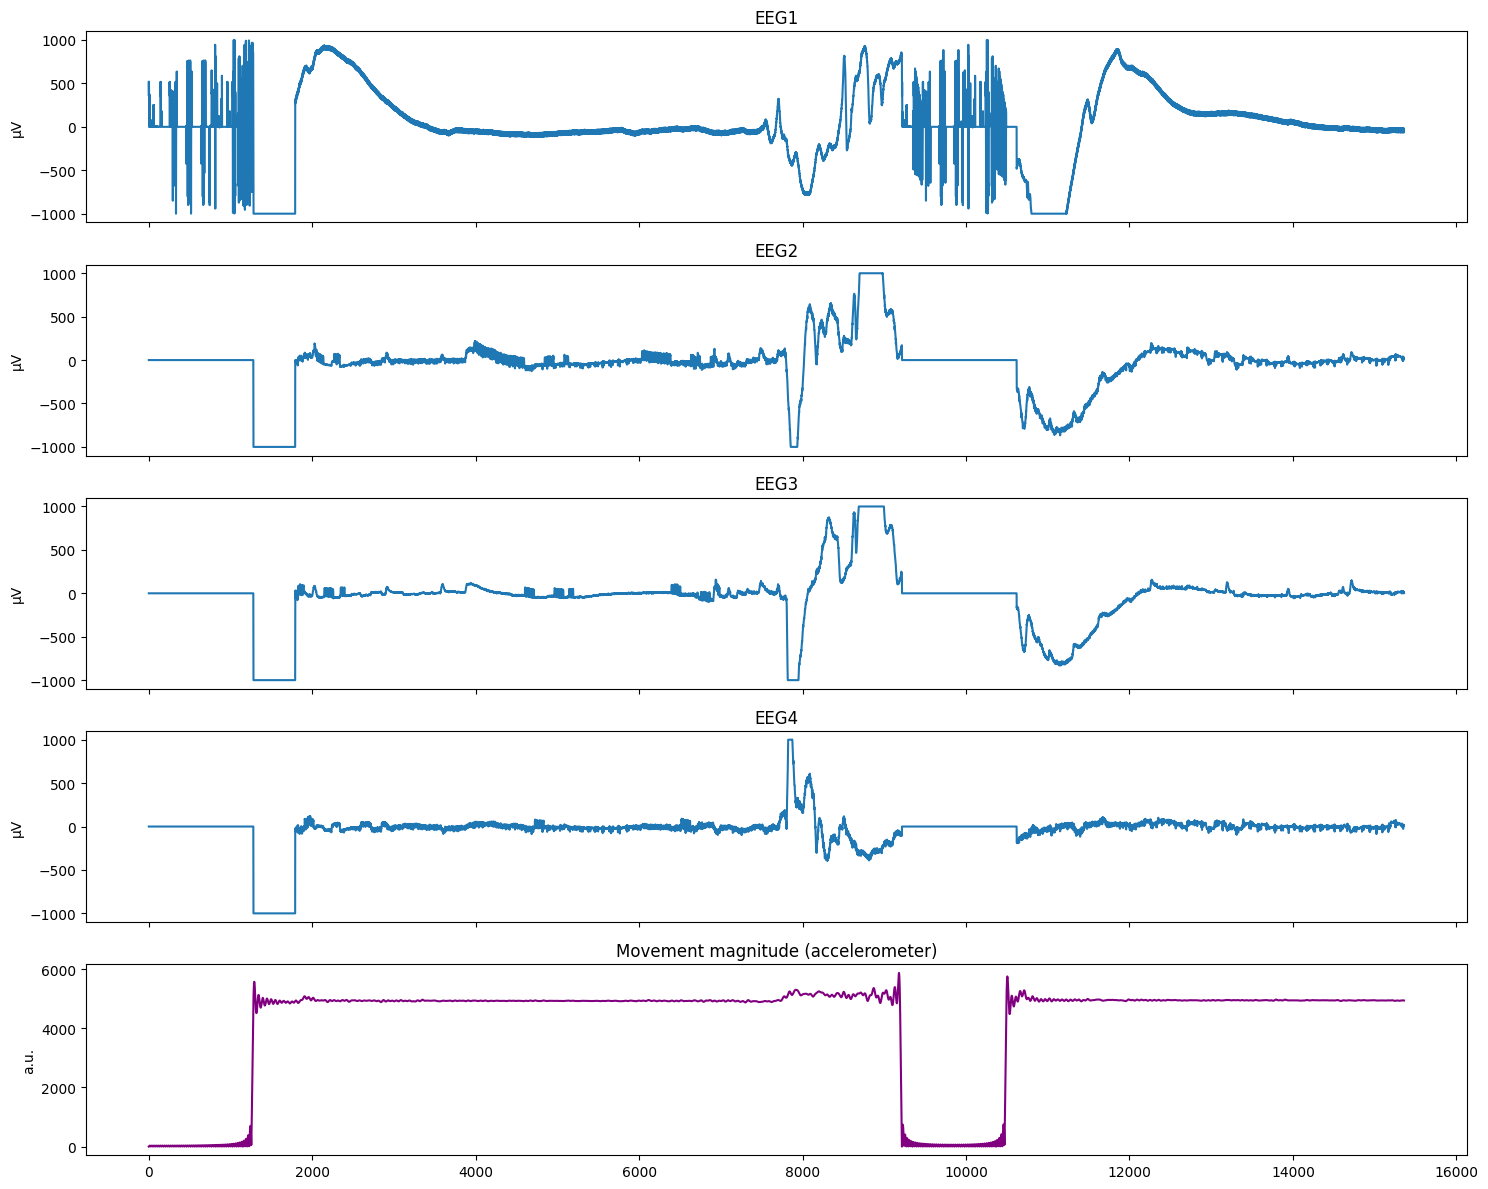

In [123]:
import matplotlib.pyplot as plt
import numpy as np

sf = int(raw.info['sfreq'])

# Compute movement magnitude from 3-axis accelerometer
tilt1 = raw.get_data(picks='Tilt1')[0]
tilt2 = raw.get_data(picks='Tilt2')[0]
tilt3 = raw.get_data(picks='Tilt3')[0]
movement = np.sqrt(tilt1**2 + tilt2**2 + tilt3**2)

# Plot movement alongside all 4 EEG channels for a window
# containing a known artifact period
window = slice(0, 60 * sf)

fig, axes = plt.subplots(5, 1, figsize=(15, 12), sharex=True)
for i, ch in enumerate(['EEG1','EEG2','EEG3','EEG4']):
    d = raw.get_data(picks=ch)[0] * 1e6
    axes[i].plot(d[window])
    axes[i].set_title(ch)
    axes[i].set_ylabel('µV')

axes[4].plot(movement[window], color='purple')
axes[4].set_title('Movement magnitude (accelerometer)')
axes[4].set_ylabel('a.u.')
plt.tight_layout()
plt.show()

Estimated heart rate: 102.0 bpm


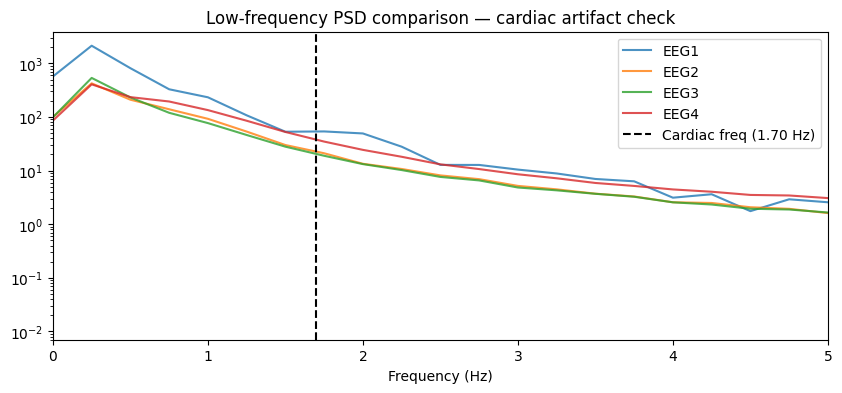

In [124]:
from scipy.signal import find_peaks

# Extract a PPG signal from IRED (infrared is typically cleaner for pulse)
ired = raw.get_data(picks='IRED')[0]
sf = raw.info['sfreq']

# Find pulse peaks in a clean segment
segment = ired[:int(60 * sf)]
peaks, _ = find_peaks(segment, distance=int(0.5 * sf))  # minimum 0.5s between beats
heart_rate = 60 / (np.diff(peaks) / sf)
print(f"Estimated heart rate: {heart_rate.mean():.1f} bpm")

# Check EEG channels for periodicity at cardiac frequency
# If EEG1 shows stronger cardiac-frequency power than EEG2/3/4,
# that supports referential channel interpretation
cardiac_freq = heart_rate.mean() / 60  # Hz

from scipy.signal import welch
fig, ax = plt.subplots(figsize=(10, 4))
for ch in ['EEG1','EEG2','EEG3','EEG4']:
    d = raw.get_data(picks=ch)[0] * 1e6
    freqs, psd = welch(d, sf, nperseg=int(sf * 4))
    ax.semilogy(freqs, psd, label=ch, alpha=0.8)
ax.axvline(cardiac_freq, color='black', linestyle='--', label=f'Cardiac freq ({cardiac_freq:.2f} Hz)')
ax.set_xlim(0, 5)
ax.set_xlabel('Frequency (Hz)')
ax.legend()
plt.title('Low-frequency PSD comparison — cardiac artifact check')
plt.show()

## Computer Power Spectral Density

I can 'call' this function in MNE to get power channel density pretty easily, but I'm still learning how to interpret this output and haven't cleaned any data yet.

Effective window size : 8.000 (s)
Need more than one channel to make topography for eeg. Disabling interactivity.


/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_65100/3175881629.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=50).plot(picks='data', exclude='bads', amplitude=False)
/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/mne/viz/utils.py:165: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


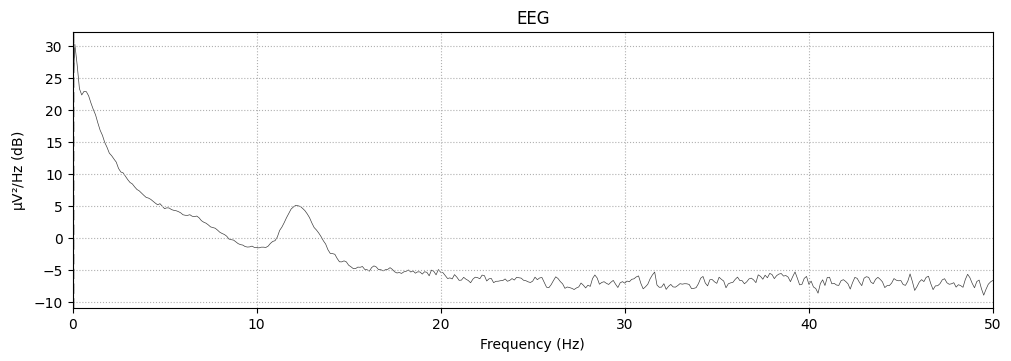

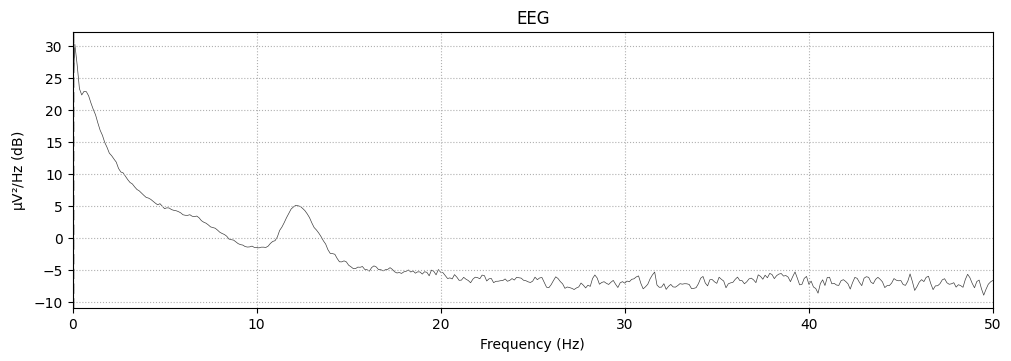

In [125]:
raw.compute_psd(fmax=50).plot(picks='data', exclude='bads', amplitude=False)

# Resume Project analysis

## Import hypnogram

Here, I'm importing the hypnogram that goes with the EEG.edf file (Kelly S test is the sleep data I'm using for sorting everything out.)

Looking at columns below:
- Primary autostage is SleepProfiler's initial scoring of each 30-s epoch, 
- Secondary autostage would be the classification if a stage was "light N2" or had partial scoring between two stages, 
- TechEditStage would be the epoch's score if a researcher manually changed that epoch's stage from Sleep Profiler's algorithm
- Stagefinal is the final score for each 30-s epoch (each row = 30s epoch).

In [126]:
## import hypnogram
hypno = pd.read_csv('KellyS_epoch_data.csv')

hypno.head()

,Subject #,Epoch #,Night,StudyDate,ElapsedTime,ElapsedTime(sec),ClockTime,PrimaryAutoStage,SecondaryAutoStage,TechEditStage,Stage final,ChannelStaged,ImpLEOG,ImpREOG,ImpEEG
0,421000303,1,1,13-Feb-25,0:00:31,31,1:02:22,0,0,NaN,0,EEG,4,2,6
1,421000303,2,1,13-Feb-25,0:01:01,61,1:02:52,0,0,NaN,0,EEG,4,2,6
2,421000303,3,1,13-Feb-25,0:01:31,91,1:03:22,0,0,NaN,0,EEG,4,2,6
3,421000303,4,1,13-Feb-25,0:02:01,121,1:03:52,0,0,NaN,0,EEG,4,2,6
4,421000303,5,1,13-Feb-25,0:02:31,151,1:04:22,0,0,NaN,0,EEG,4,2,6


In [127]:
hypno.describe()
## count = 899 of 30 second epochs = 449.5 minutes

,Subject #,Epoch #,Night,ElapsedTime(sec),PrimaryAutoStage,SecondaryAutoStage,TechEditStage,Stage final,ImpLEOG,ImpREOG,ImpEEG
count,899.0,899.000000,899.0,899.000000,899.000000,899.000000,0.0,899.000000,899.000000,899.000000,899.000000
mean,421000303.0,450.000000,1.0,13501.000000,2.652948,2.598443,NaN,2.652948,1.529477,26.291435,35.028921
std,0.0,259.663243,0.0,7789.897304,1.344675,1.372672,NaN,1.344675,0.760940,75.325483,85.211653
min,421000303.0,1.000000,1.0,31.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
25%,421000303.0,225.500000,1.0,6766.000000,2.000000,2.000000,NaN,2.000000,1.000000,1.000000,1.000000
50%,421000303.0,450.000000,1.0,13501.000000,2.000000,2.000000,NaN,2.000000,1.000000,1.000000,1.000000
75%,421000303.0,674.500000,1.0,20236.000000,3.000000,3.000000,NaN,3.000000,2.000000,2.000000,2.000000
max,421000303.0,899.000000,1.0,26971.000000,5.000000,5.000000,NaN,5.000000,4.000000,252.000000,252.000000


In [128]:
hypno.columns = hypno.columns.str.lower().str.replace(' ', '_')

hypno.columns

Index(['subject_#', 'epoch_#', 'night', 'studydate', 'elapsedtime',
       'elapsedtime(sec)', 'clocktime', 'primaryautostage',
       'secondaryautostage', 'techeditstage', 'stage_final', 'channelstaged',
       'impleog', 'impreog', 'impeeg'],
      dtype='object')

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_65100/1964525906.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(stage_labels.values())


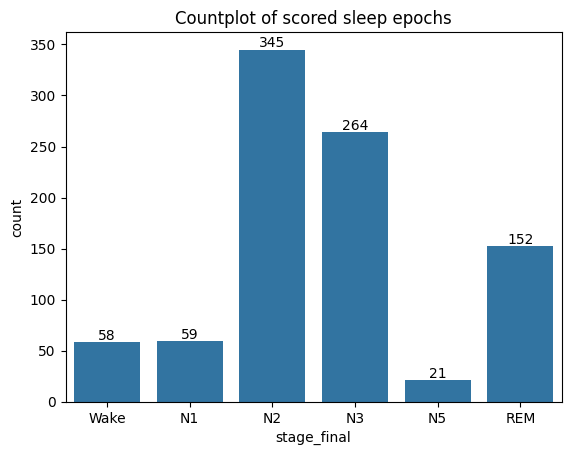

In [129]:
ax = sns.countplot(data= hypno, x='stage_final')
ax.bar_label(ax.containers[0], label_type = 'edge')

## labels based on SleepProfiler documentation
stage_labels = {
    0 : 'Wake',
    1 : 'N1',
    2 : 'N2',
    3 : 'N3', 
    4 : 'N5',
    5 : 'REM'
}

ax.set_xticklabels(stage_labels.values())
ax.set_title('Countplot of scored sleep epochs')
plt.show()

## 899 total count (30s) = 449.5 min, the TIB values from hypnogram.sleep_statistics() below

### MNE Raw methods and attributes for potential use:

This is just a placeholder for potential functions (methods/attributes) I might use for this process. As I'm reading through documentation, I'm just placing these here for future reference.


- raw.crop() can isolate a window of time (seconds) including start/stop as arguments.
- raw.rename_channels()
- raw.drop_channels()
- raw.get_data() for if you want the data and not the corresponding array of times

### Spectrum and EpochsSpectrum classes: frequency-domain data

source: 
https://mne.tools/stable/auto_tutorials/time-freq/10_spectrum_class.html

### MNE Preprocessing documentation

https://mne.tools/stable/api/preprocessing.html

- MNE preprocessing Independent Component Analysis (ICA) available but lengthy documentation

I don't know if this is relevant but flagged it anyways.

## Pre-processing stage: Artifact removal

# Roadblock #2: Verifying EEG and hypnogram data align, and determining the level of 'agreement' between SleepProfiler's autostaging algorithm vs. YASA's autoscoring feature.

**Explained:** SleepProfiler's autostaging algorithm has a Cohen's kappa coefficient of κ=0.67, which is considered "substantial agreement" between its auto-staging feature compared to a panel of sleep experts. This level of agreement is in line with any other at-home sleep-monitoring EEG device. 

What this section is working on is determining how well YASA's sleep staging algorithm lines up with SleepProfiler's autostaging algorithm. Eventually, I'd like to run a Cohen's kappa coefficient between the results of each on the same EEG.edf file. However, this will only tell me how well these algorithms agree with each other, not their true accuracy (compared to manual scoring by sleep expert(s).)

**Issues:**
- Both YASA and SleepProfiler use AASM criteria for scoring; however, SleepProfiler explicitly states they have some deviations in their scoring methods compared to the actual AASM scoring criteria. 
- For the below sleep_statistics, YASA removes epochs that are marked as 'artifact' or 'unscored' which I don't have a problem with, but will probably cause the results to drift somewhat from SleepProfiler's. 
- For YASA, there are 5 scoring criteria used for macroarchitecture (Awake, N1,N2,N3,REM) but in the next cell, you'll find 11 potential scoring options in the SleepProfiler data (found in Sleep Profiler's documentation).


**Question:** 
1. In the next cell, next to certain staging scores, I've commented in the ## what I would change that stage to during the pre-processing stage so that it maps correctly for determining sleep_statistics later on. Do those options seem appropriate to you? (e.g., mapping light N2 as N2 fine...is mapping REM without atonia as REM an issue?)

In [130]:
## map hypnogram stages based on SleepProfiler stage scoring documentation
stage_map = {
    0 : 'WAKE',
    1: 'N1',
    2: 'N2',
    3: 'N3',
    4: 'N2', ## Light N2 (Still N2)
    5: 'REM', 
    6: 'UNS', ## sleep not otherwise specified
    9: 'UNS', ## artifact/ INVALID
    14: 'N2',
    33: 'N3', ## atypical N3, mapped to N3
    55: 'REM' ## REM without atonia, mapped to REM
}

hypno_sorted = hypno.sort_values('epoch_#').copy()
hypno_sorted['yasa_stage'] = hypno_sorted['stage_final'].map(stage_map)

# Check nothing fell through unmapped
print(hypno_sorted["yasa_stage"].isna().sum(), "unmapped epochs")

stage_sequence = hypno_sorted["yasa_stage"].values
hyp = yasa.Hypnogram(stage_sequence, freq="30s")

0 unmapped epochs


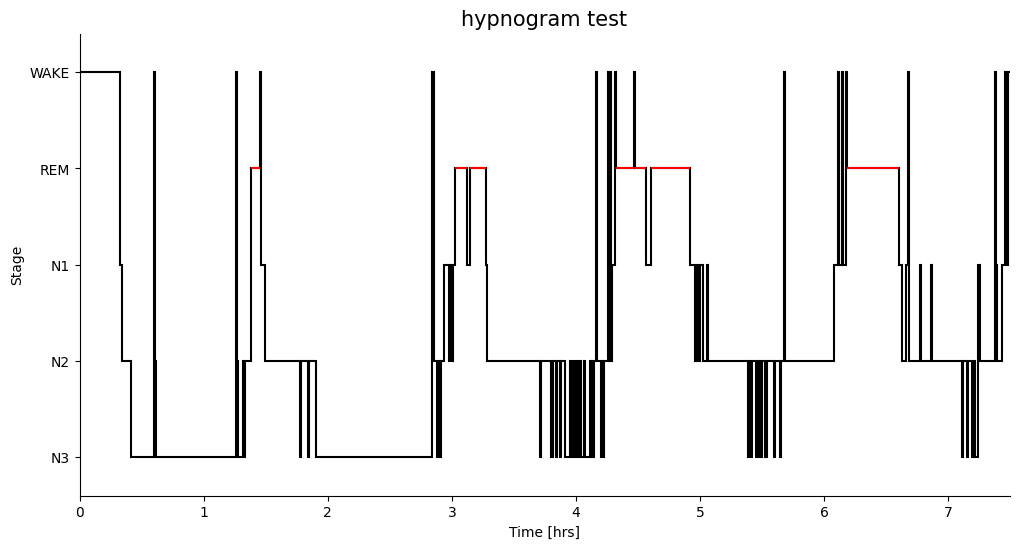

In [131]:
fig, ax = plt.subplots(figsize=(12,6))

ax = hyp.plot_hypnogram()

plt.title('hypnogram test', fontsize=15)
plt.show()

# Basic sleep statistics

## Roadblock #3 Comparing sleep statistics from YASA vs. SleepProfiler

**Explained:**

YASA has a very simple function below to report a bunch of sleep statistics. Most but not all are provided by SleepProfiler. I'm currently determining which variable from each program relate to one another. For example YASA reports time in bed of 449.5 (based on the number of 30-s epochs included in the hypnogram data), whereas SleepProfiler reports a sleep time of 7.55 hours (453 minutes.) Close, but slightly different.

Again, YASA doesn't count epochs that are scored as artifact or 'unscored' but you'll see below that the numbers are slighlty off. I'm still working on fine-turning the data and trying to determine if there's any cleaning I need to do prior to churning out these sleep statistics. 

Generally, this function works but I think there's still some cleaning up to do before I feel very confident in these numbers.

**Potential step to add:**
Depending on if this will help or not, I may try to map the EEG data based on sleep diary-reported sleep_start and sleep_end times, which could potentially remove excessive artifact/data captured while the participant's wore the headband but weren't immediately going to bed. This would clean the data up but might not be necessary based on how the EEG data is captured and reported. 




In [132]:
449.5 /60
## checking YASA TIB in hours and minutes

7.491666666666666

In [133]:
7.55*60
## checking SleepProfiler Total sleep in hours vs. minutes (called "total sleep" in SleepProfiler report)

453.0

Below are the following variables reported from running hypnogram.sleep_statistics. Results from the test_files (KellyS) are reported below each variable with SP indicating the SleepProfiler equivalent.

- **Time in Bed (TIB):** total duration (min) of the hypnogram.
  - 449.5 min
  - SP recording time(study time) = 8.07 h (484.2 min) 
  - **Note:** hypnogram.sleep_statistics automatically excluded epochs listed as 'artifact' or 'unscored.'

- **Sleep Period Time (SPT):** duration (min) from first to last period of sleep. (aka sleep duration)
  - 429.5
- **Wake After Sleep Onset (WASO):** duration of wake periods within SPT.
  - 9.0
- **Total Sleep Time (TST):** total sleep duration in SPT. calculated as the sum of all REM and NREM sleep in SPT
  - 420.5
  - 453 (SP 7.55 h)
- **Sleep Onset Latency (SOL):** Latency to first epoch of any sleep.
  - 19.5
  - 15 (SP)
- **SOL 5min:** Latency to 5 minutes of persistent sleep (any stage).
  - 19.5
- **REM latency:** latency to first REM sleep.
  - 83.0
- **Sleep Efficiency (SE):** TST / TIB * 100 (%).
  - 93.55%
- **Sleep Maintenance Efficiency (SME):** TST / SPT * 100 (%).
  - 97.91%
- **Sleep Fragmentation Index:** number of transitions from sleep to wake / hours of TST
- 1.21
- **Sleep stages amount and proportion of TST**
  - WAKE
    - 29
    - 31.2 SP(0.52h)
  - REM 
    - 76
    - 54 SP(0.90h)
  - N1
    - 29.5
    - 54 SP(0.9h)
  - N2
    - 183
    - 199.8 SP(3.33h)
  - N3
    - 132
    - 145.2 SP(2.42h)
  

In [134]:
hyp.sleep_statistics()

## checking these values out vs. what Sleep Profiler (SP) reports from their autostaging algorithm (intial output)

## in SP, sleep_onset (first 30-s sleep epoch) is at 0:14:43 from beginning of study period (SOL/SOL_5min in this output says 19.5, so 5-min offset?).

##SP study period was 8.1 hours (486 min) with 0 minutes of excluded time, TST = 7.6 hours (456 min). 

## study_start time_date = 07:26:00 on 2/10/2025
## end_time = 15:29:59
## total study time (recording time) = 8.07 h
## sleep time = 7.55 h
## Sleep efficiency = 93.6%
## Wake = 6.4% (0.52 h)
## Stage R = 11.9% (0.9h)
## N1 = 11.9% (0.9h)
## N2 = 44.2% (3.33h)
## N3 = 32% (2.42h)
## Sleep latency = 15min
## WASO = 16min
## N3 latency = 2min
## REM latency = 102min
#### Sleep Continuity metrics ######
## cortical arousals/hr = 7.7
## microarousals/hr- other = 2.0
## awakenings/hr ≥30seconds = 2.3
## awakenings/hr ≥90s = 0.4
## movement arousals/hr = 2.0
## spindle duration (min) = 25.28 min

{'TIB': 449.5,
 'SPT': 429.5,
 'WASO': 9.0,
 'TST': 420.5,
 'SE': 93.5484,
 'SME': 97.9045,
 'SFI': 1.2128,
 'SOL': 19.5,
 'SOL_5min': 19.5,
 'Lat_REM': 83.0,
 'WAKE': 29.0,
 'N1': 29.5,
 'N2': 183.0,
 'N3': 132.0,
 'REM': 76.0,
 '%N1': 7.0155,
 '%N2': 43.5196,
 '%N3': 31.3912,
 '%REM': 18.0737}

In [135]:
round((429.5/449.5)*100, 2)

95.55

In [136]:
counts, probs = hyp.transition_matrix()

## counts = number of transitions from stage A to B. pre-transition states are the rows and the post-transition states are the columns
display(counts)

## conditional probability transition matrix, i.e., given that current state is A, what is the probability that the next state is B. Stochastic matrix
display(probs.round(3))

To Stage,WAKE,N1,N2,N3,REM
From Stage,,,,,
WAKE,40,6,8,0,3
N1,7,35,14,0,3
N2,5,12,313,35,1
N3,3,1,31,229,0
REM,2,5,0,0,145


To Stage,WAKE,N1,N2,N3,REM
From Stage,,,,,
WAKE,0.702,0.105,0.140,0.000,0.053
N1,0.119,0.593,0.237,0.000,0.051
N2,0.014,0.033,0.855,0.096,0.003
N3,0.011,0.004,0.117,0.867,0.000
REM,0.013,0.033,0.000,0.000,0.954


In [137]:
## the stability of sleep can be calculated by taking the average of the diagonal values of N2, N3, and REM sleep

np.diag(probs.loc['N2':, "N2":]).mean().round(3)

0.892

In [138]:
data_chan = raw.get_data(picks='EEG4')[0]

sf = raw.info['sfreq']

In [139]:
raw.info['sfreq']

256.0

## Spectrogram

# Roadblock #4 Spectrogram, I don't know what I'm doing here (yet)

**explained.** I'm still learning on how to interpret this and am not sure what to do with this information, but it's a pretty picture nonetheless and looks like a hypnogram/spectrogram.

26-Aug-26 17:06:17 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


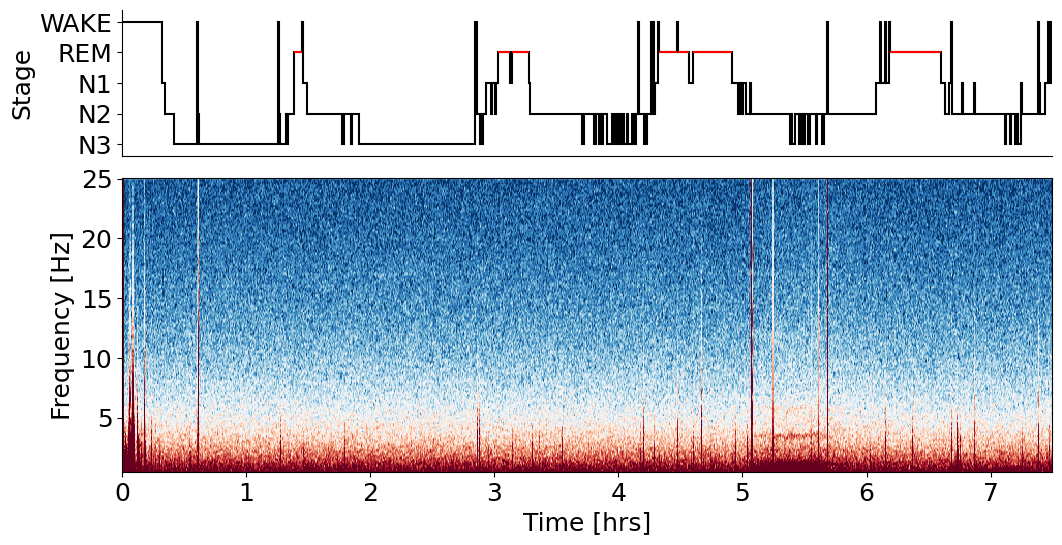

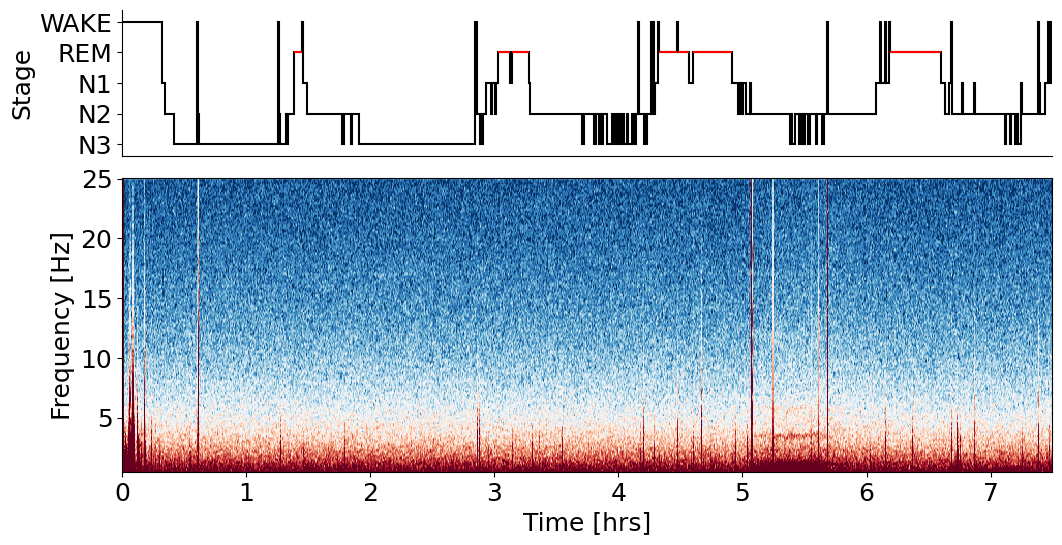

In [140]:
## change these settings prior to plotting spectrogram, as needed
data_chan = raw.get_data(picks='EEG1')[0]
sf = raw.info['sfreq']

yasa.plot_spectrogram(data_chan, sf, hyp)

26-Aug-26 17:06:18 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


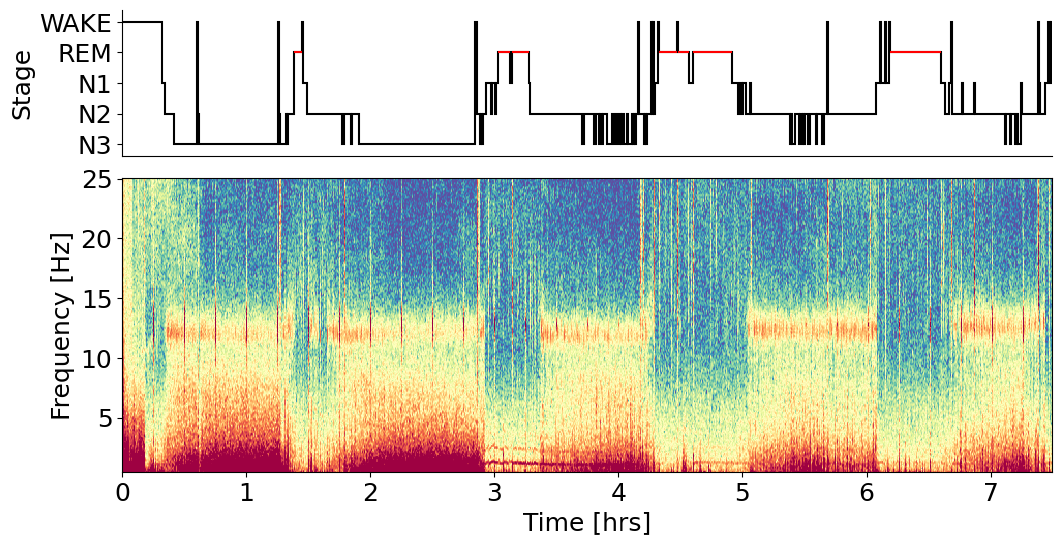

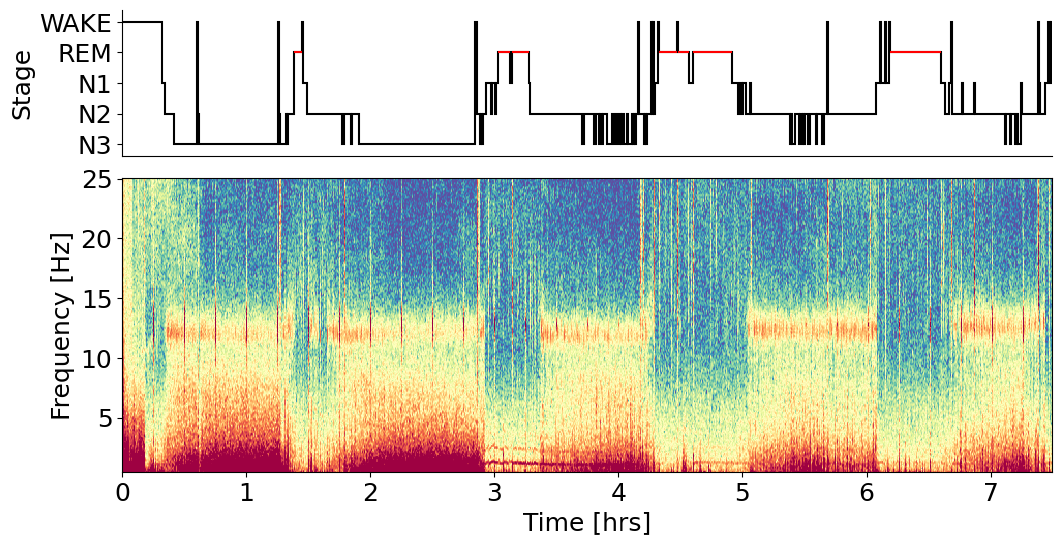

In [141]:
## change these settings prior to plotting spectrogram, as needed
data_chan = raw.get_data(picks='EEG2')[0]
sf = raw.info['sfreq']

yasa.plot_spectrogram(data_chan, sf, hyp, cmap='Spectral_r')

26-Aug-26 17:06:18 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


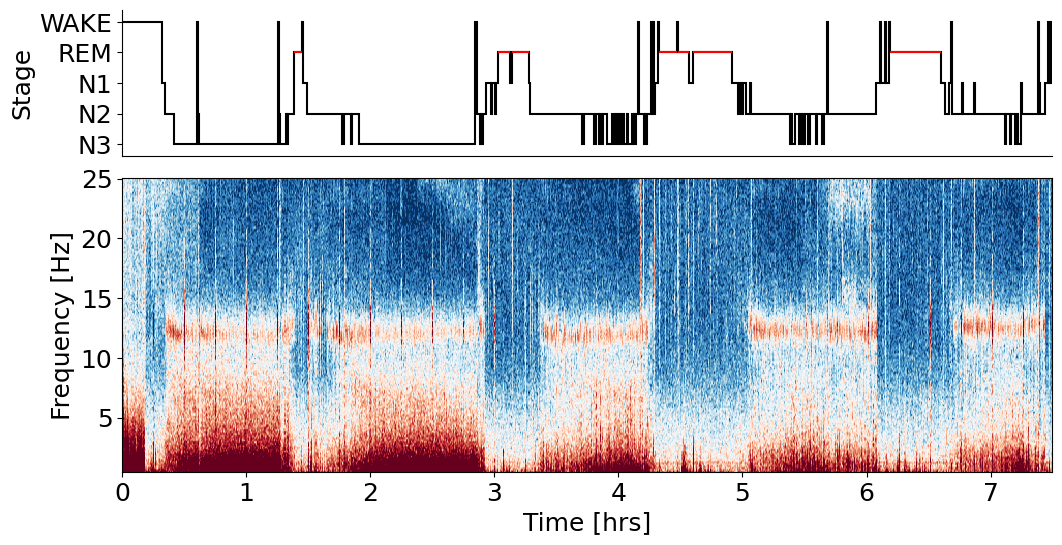

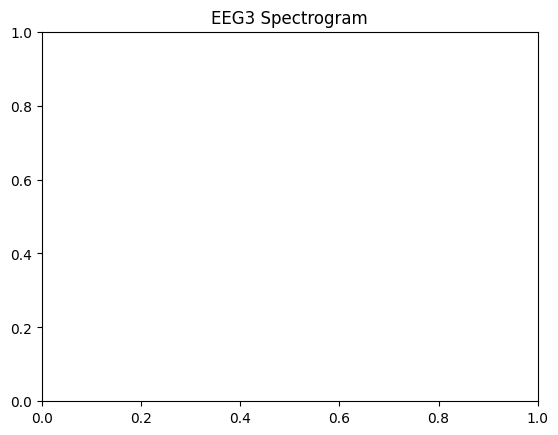

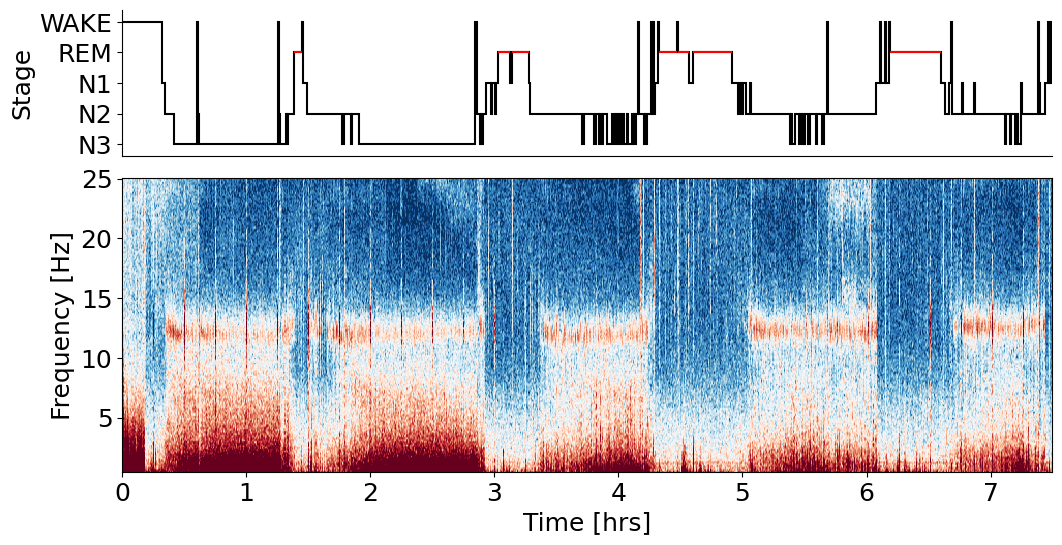

In [142]:
## change these settings prior to plotting spectrogram, as needed
data_chan = raw.get_data(picks='EEG3')[0]
sf = raw.info['sfreq']

plt.title('EEG3 Spectrogram')
yasa.plot_spectrogram(data_chan, sf, hyp)

26-Aug-26 17:06:19 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


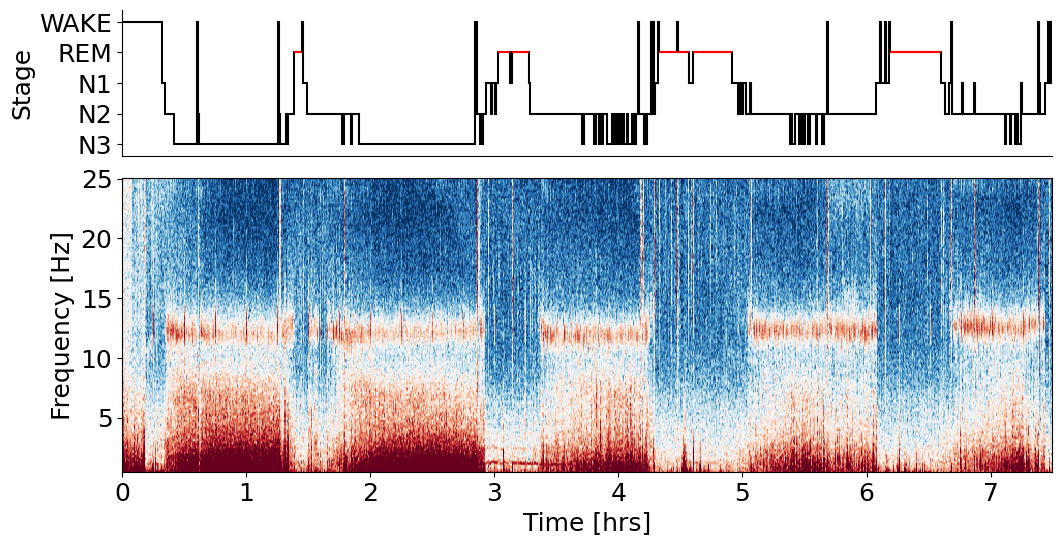

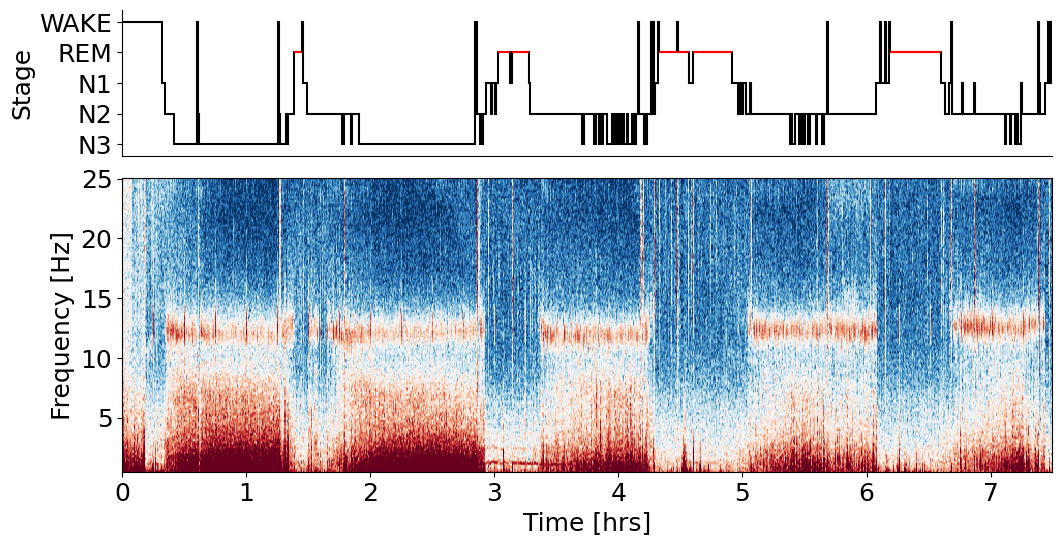

In [143]:
## change these settings prior to plotting spectrogram, as needed
data_chan = raw.get_data(picks='EEG4')[0]
sf = raw.info['sfreq']

yasa.plot_spectrogram(data_chan, sf, hyp)

In [144]:
## EEG power in specific frequency bands
## default is that this is in relative power across all channels
yasa.bandpower(raw)

,Delta,Theta,Alpha,Sigma,Beta,Gamma,TotalAbsPow,FreqRes,Relative
Chan,,,,,,,,,
EEG1,0.862323,0.069138,0.024501,0.013201,0.022314,0.008523,8.651418,0.25,True
EEG2,0.814777,0.096311,0.037733,0.024997,0.020792,0.005390,24.223728,0.25,True
EEG3,0.791590,0.104452,0.043975,0.029124,0.024477,0.006382,21.503423,0.25,True
EEG4,0.773219,0.116793,0.046958,0.033028,0.025094,0.004910,43.406059,0.25,True
Tilt1,0.773101,0.226861,0.000022,0.000007,0.000007,0.000002,35.602820,0.25,True
Tilt2,0.643184,0.356770,0.000026,0.000010,0.000009,0.000002,33.123317,0.25,True
Tilt3,0.751290,0.248679,0.000017,0.000006,0.000006,0.000002,27.493463,0.25,True
IRED,0.988882,0.008582,0.000758,0.000286,0.000941,0.000551,0.000009,0.25,True
RED,0.988882,0.008582,0.000758,0.000286,0.000941,0.000551,0.000009,0.25,True


In [145]:
## EEG power in specific frequency bands
## here is the absolute power across all channels
## yuck to look at
yasa.bandpower(raw, relative=False)

,Delta,Theta,Alpha,Sigma,Beta,Gamma,TotalAbsPow,FreqRes,Relative
Chan,,,,,,,,,
EEG1,7.460316,5.981405e-01,2.119714e-01,1.142063e-01,1.930438e-01,7.373996e-02,8.651418,0.25,False
EEG2,19.736933,2.333014e+00,9.140319e-01,6.055315e-01,5.036560e-01,1.305623e-01,24.223728,0.25,False
EEG3,17.021894,2.246066e+00,9.456187e-01,6.262600e-01,5.263462e-01,1.372379e-01,21.503423,0.25,False
EEG4,33.562370,5.069504e+00,2.038243e+00,1.433623e+00,1.089211e+00,2.131082e-01,43.406059,0.25,False
Tilt1,27.524576,8.076886e+00,7.740423e-04,2.662930e-04,2.554310e-04,6.221441e-05,35.602820,0.25,False
Tilt2,21.304384,1.181739e+01,8.582870e-04,3.189429e-04,2.942648e-04,6.759097e-05,33.123317,0.25,False
Tilt3,20.655571,6.837045e+00,4.757226e-04,1.518435e-04,1.727112e-04,4.712207e-05,27.493463,0.25,False
IRED,0.000009,7.537948e-08,6.658274e-09,2.513653e-09,8.262743e-09,4.837703e-09,0.000009,0.25,False
RED,0.000009,7.537948e-08,6.658274e-09,2.513653e-09,8.262743e-09,4.837703e-09,0.000009,0.25,False


In [146]:
## can also pass a hypnogram to calculate the spectral powers separately for each sleep stage. In the example belo, we pass hypnogram object directly and use string stage labels for include. then, save the results in a new variable named 'bandpower'
bandpower = yasa.bandpower(raw, hypno = hyp, include=['N2', 'N3', 'REM'])

bandpower

26-Aug-26 17:06:25 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


Delta     Theta     Alpha     Sigma      Beta     Gamma  \
Stage Chan                                                                
2     EEG1   0.877149  0.061800  0.022122  0.011669  0.019754  0.007506   
      EEG2   0.758818  0.103790  0.057123  0.050626  0.024263  0.005380   
      EEG3   0.732061  0.107938  0.066337  0.057893  0.029092  0.006678   
      EEG4   0.710564  0.121066  0.068695  0.063850  0.030283  0.005542   
      Tilt1  0.750963  0.248999  0.000022  0.000007  0.000007  0.000002   
      Tilt2  0.679417  0.320542  0.000024  0.000008  0.000007  0.000002   
      Tilt3  0.749757  0.250212  0.000017  0.000006  0.000006  0.000002   
      IRED   0.988617  0.008899  0.000836  0.000283  0.000871  0.000494   
      RED    0.988617  0.008899  0.000836  0.000283  0.000871  0.000494   
      Snore  0.812521  0.187441  0.000019  0.000007  0.000010  0.000003   
3     EEG1   0.850657  0.074710  0.026489  0.014270  0.024505  0.009369   
      EEG2   0.933051  0.043055  0.013677  0.006535  0.002673  0.001009   
      EEG3   0.926660  0.045438  0.015794  0.007917  0.003103  0.001087   
      EEG4   0.923541  0.049839  0.014855  0.008527  0.002712  0.000527   
      Tilt1  0.787984  0.211981  0.000020  0.000006  0.000006  0.000002   
      Tilt2  0.568870  0.431090  0.000024  0.000008  0.000007  0.000002   
      Tilt3  0.755324  0.244644  0.000017  0.000006  0.000007  0.000002   
      IRED   0.984107  0.014159  0.000562  0.000180  0.000627  0.000365   
      RED    0.984107  0.014159  0.000562  0.000180  0.000627  0.000365   
      Snore  0.882932  0.117041  0.000013  0.000005  0.000007  0.000002   
4     EEG1   0.848084  0.075502  0.026728  0.014896  0.025060  0.009729   
      EEG2   0.709684  0.135725  0.037604  0.026418  0.074180  0.016388   
      EEG3   0.708638  0.136062  0.039467  0.027281  0.071919  0.016633   
      EEG4   0.673135  0.150911  0.046396  0.031476  0.080664  0.017417   
      Tilt1  0.793733  0.206220  0.000021  0.000009  0.000013  0.000004   
      Tilt2  0.660599  0.339352  0.000026  0.000010  0.000010  0.000002   
      Tilt3  0.750444  0.249522  0.000020  0.000006  0.000006  0.000002   
      IRED   0.985307  0.011307  0.000791  0.000399  0.001361  0.000835   
      RED    0.985307  0.011307  0.000791  0.000399  0.001361  0.000835   
      Snore  0.817353  0.182609  0.000019  0.000007  0.000009  0.000003   

             TotalAbsPow  FreqRes  Relative  
Stage Chan                                   
2     EEG1      9.956333     0.25      True  
      EEG2     20.317815     0.25      True  
      EEG3     18.217541     0.25      True  
      EEG4     38.376501     0.25      True  
      Tilt1    34.312961     0.25      True  
      Tilt2    32.198155     0.25      True  
      Tilt3    26.938762     0.25      True  
      IRED      0.000008     0.25      True  
      RED       0.000008     0.25      True  
      Snore     0.000197     0.25      True  
3     EEG1      7.822627     0.25      True  
      EEG2    155.534178     0.25      True  
      EEG3    144.633210     0.25      True  
      EEG4    303.299516     0.25      True  
      Tilt1    34.933766     0.25      True  
      Tilt2    34.723414     0.25      True  
      Tilt3    25.423625     0.25      True  
      IRED      0.000016     0.25      True  
      RED       0.000016     0.25      True  
      Snore     0.000433     0.25      True  
4     EEG1      7.484130     0.25      True  
      EEG2      7.177749     0.25      True  
      EEG3      7.030721     0.25      True  
      EEG4     14.019210     0.25      True  
      Tilt1    40.326376     0.25      True  
      Tilt2    33.528610     0.25      True  
      Tilt3    31.839415     0.25      True  
      IRED      0.000006     0.25      True  
      RED       0.000006     0.25      True  
      Snore     0.000204     0.25      True

# Events detection

## Sleep Spindles

In [147]:
sp = yasa.spindles_detect(raw, hypno= hyp, include=['N2', 'N3'])

sp.summary()

## sp variable is a SpindlesResults (bundle of functions called methods) and data (attributes). 



26-Aug-26 17:06:27 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
26-Aug-26 17:06:27 | ERROR | Wrong data amplitude for IRED (trimmed STD = 0.003). Unit of data MUST be uV! Channel will be skipped.
26-Aug-26 17:06:27 | ERROR | Wrong data amplitude for RED (trimmed STD = 0.003). Unit of data MUST be uV! Channel will be skipped.
26-Aug-26 17:06:27 | ERROR | Wrong data amplitude for Snore (trimmed STD = 0.019). Unit of data MUST be uV! Channel will be skipped.
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.8s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.8s finished
26-Aug-26 17:06:35 | WARNING | No spindle were found in channel EEG1.
26-Aug-26 17:06:40 | WARNING | No spindle were found in channel Tilt1.
26-Aug-26 17:06:41 | WARNING | No spindle were found in channel Tilt2.
26-Aug-26 17:06:42 | WARNING | No spindle were found in channel Tilt3.


,Start,Peak,End,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry,Stage,Channel,IdxChannel
0,1252.160156,1252.558594,1252.925781,0.765625,20.886334,12.272031,4.704586,1.405003,0.365855,12.532904,10.0,0.517766,2,EEG2,1
1,1259.785156,1260.375000,1260.644531,0.859375,40.152783,29.242797,8.303294,1.759656,0.513557,12.371677,11.0,0.683258,2,EEG2,1
2,1268.210938,1268.531250,1269.195312,0.984375,23.244416,13.364514,4.573223,1.287185,0.390466,12.212155,12.0,0.324111,2,EEG2,1
3,1274.898438,1275.152344,1275.605469,0.707031,16.702848,11.416439,4.134046,1.277146,0.446500,12.543069,9.0,0.357143,2,EEG2,1
4,1306.953125,1307.812500,1308.289062,1.335938,39.966575,29.259833,8.663382,1.912844,0.550061,12.418883,16.0,0.641399,2,EEG2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3614,26726.738281,26727.050781,26727.425781,0.687500,27.124713,18.829397,5.952717,1.668712,0.547866,13.218066,9.0,0.451977,2,EEG4,3
3615,26738.371094,26738.847656,26739.406250,1.035156,45.976382,28.786705,9.626578,2.175429,0.671251,13.050696,14.0,0.458647,2,EEG4,3
3616,26741.902344,26742.300781,26742.796875,0.894531,52.454372,43.522232,11.304587,2.210276,0.646790,12.942289,12.0,0.443478,2,EEG4,3
3617,26748.722656,26749.187500,26749.683594,0.960938,33.468267,17.886285,7.587170,1.785331,0.517889,12.753991,12.0,0.481781,2,EEG4,3


In [148]:
sp.summary(grp_chan=True, grp_stage=True)

## specifying grp_chan and grp_stage parameters tells YASA to first average across channels and sleep stages

Count   Density  Duration  Amplitude  AmpFiltered        RMS  \
Stage Channel                                                                 
2     EEG2       982  5.366120  0.919476  26.025726    16.345576   5.673552   
      EEG3      1060  5.792350  0.941462  26.938794    17.402295   5.943255   
      EEG4      1105  6.038251  0.935276  38.269948    24.256031   8.326675   
3     EEG2       126  0.954545  0.855159  34.679831    21.978293   7.957742   
      EEG3       181  1.371212  0.832592  39.026911    26.145186   9.123879   
      EEG4       165  1.250000  0.830658  46.292419    28.684517  10.417635   

               AbsPower  RelPower  Frequency  Oscillations  Symmetry  
Stage Channel                                                         
2     EEG2     1.484673  0.447032  12.536281     11.312627  0.499802  
      EEG3     1.501511  0.453622  12.477569     11.528302  0.514597  
      EEG4     1.830783  0.459964  12.471021     11.415385  0.502539  
3     EEG2     1.625001  0.377008  12.418603     10.428571  0.503740  
      EEG3     1.708091  0.378722  12.414979     10.033149  0.519099  
      EEG4     1.964526  0.378663  12.383619     10.006061  0.485398

### Plot of average spindle

# Roadblock #5 Sleep Spindle and Slow-wave characteristics data

**Explained:**
I'm not far enough to understand the outputs here, but should be able to capture sleep spindle characteristics including:
- spindle count (density)
- spindle frequency and duration descriptives
- Other? (not sure what else I might be able to grab)

- Slow wave visuals below show three different waveforms at different amplitudes. I'm not sure but I don't think I'd expect to see three different waveforms that far apart (I think they should generally be overlapping like the sleep spindle visual). This might be artifact or something else I need to eventually resolve. 

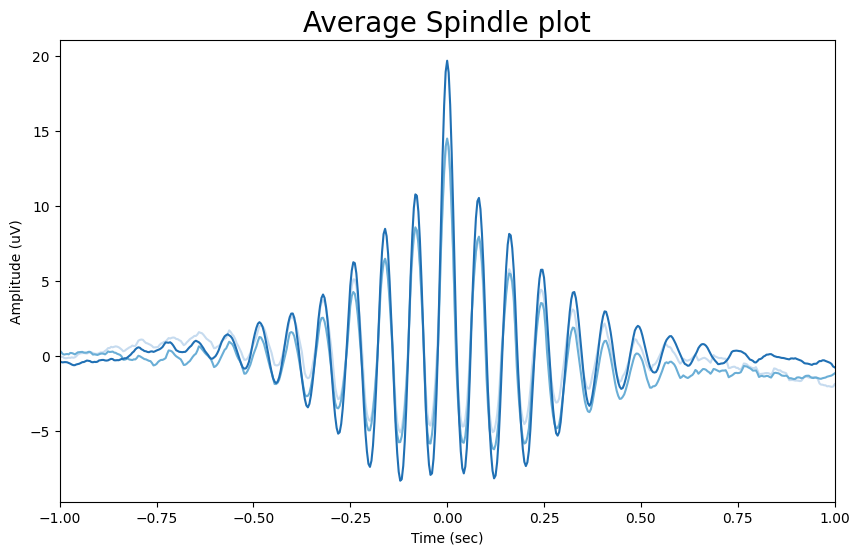

In [149]:
sp.plot_average(ci=None, legend=False, palette='Blues', figsize=(10,6))

plt.title('Average Spindle plot', fontsize=20)
plt.show()

In [150]:
sp = yasa.spindles_detect(
    raw.get_data(picks='EEG4')[0] * 1e6,  # µV, single channel
    raw.info['sfreq'],
    hypno=hyp,
    include=("N2", "N3"),   ## N2 and N3 only
    freq_sp=(12, 15), ## spindle frequency band. Can adjust for slow (11-13Hz) vs fast (13-15Hz)
    freq_broad=(1, 30),
    min_distance=500, ## ms between spindles
    # coupling=True,    ## spindle-SO coupling
)
sp_summary = sp.summary(grp_stage=True)  ## aggregate by sleep stage
print(sp_summary)

26-Aug-26 17:06:44 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


       Count   Density  Duration  Amplitude  AmpFiltered        RMS  AbsPower  \
Stage                                                                           
2       1105  6.038251  0.935276  38.269948    24.256031   8.326675  1.830783   
3        165  1.250000  0.830658  46.292419    28.684517  10.417635  1.964526   

       RelPower  Frequency  Oscillations  Symmetry  
Stage                                               
2      0.459964  12.471021     11.415385  0.502539  
3      0.378663  12.383619     10.006061  0.485398  


In [167]:
sp.summary()

,Start,Peak,End,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry,Stage,Channel,IdxChannel
0,1252.199219,1252.402344,1252.812500,0.613281,31.463677,14.734405,6.713212,1.477557,0.261957,12.606399,8.0,0.329114,2,CHAN000,0
1,1259.839844,1260.136719,1260.492188,0.652344,43.039372,25.444722,9.246004,1.818899,0.364423,12.469450,8.0,0.452381,2,CHAN000,0
2,1268.132812,1268.382812,1269.207031,1.074219,31.219279,23.042778,6.887620,1.562799,0.449959,12.472698,13.0,0.231884,2,CHAN000,0
3,1274.785156,1274.996094,1275.597656,0.812500,24.469550,16.380466,5.668907,1.648784,0.525266,12.504452,10.0,0.258373,2,CHAN000,0
4,1277.519531,1278.160156,1278.429688,0.910156,40.158593,23.218884,7.907250,1.752384,0.446534,12.688810,10.0,0.700855,2,CHAN000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1265,26726.738281,26727.050781,26727.425781,0.687500,27.124713,18.829397,5.952717,1.668712,0.547866,13.218066,9.0,0.451977,2,CHAN000,0
1266,26738.371094,26738.847656,26739.406250,1.035156,45.976382,28.786705,9.626578,2.175429,0.671251,13.050696,14.0,0.458647,2,CHAN000,0
1267,26741.902344,26742.300781,26742.796875,0.894531,52.454372,43.522232,11.304587,2.210276,0.646790,12.942289,12.0,0.443478,2,CHAN000,0
1268,26748.722656,26749.187500,26749.683594,0.960938,33.468267,17.886285,7.587170,1.785331,0.517889,12.753991,12.0,0.481781,2,CHAN000,0


In [152]:
sp_summary

,Count,Density,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry
Stage,,,,,,,,,,,
2,1105,6.038251,0.935276,38.269948,24.256031,8.326675,1.830783,0.459964,12.471021,11.415385,0.502539
3,165,1.250000,0.830658,46.292419,28.684517,10.417635,1.964526,0.378663,12.383619,10.006061,0.485398


## Slow-waves

In [169]:
# eeg_channels = ['EEG1', 'EEG2', 'EEG3', 'EEG4']
eeg_channels = ['EEG4']
raw_eeg = raw.copy().pick(eeg_channels)


sw = yasa.sw_detect(raw_eeg, hypno= hyp, include=['N2', 'N3'])

sw.summary()

26-Aug-26 17:09:25 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


,Start,NegPeak,MidCrossing,PosPeak,End,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency,Stage,Channel,IdxChannel
0,1719.386719,1719.691406,1719.953125,1720.167969,1720.421875,1.0352,-57.968922,39.683884,97.652806,221.493194,0.965997,3,EEG4,0
1,1871.105469,1871.390625,1871.707031,1872.003906,1872.359375,1.2539,-50.867305,41.846577,92.713882,160.765803,0.797512,3,EEG4,0
2,1927.859375,1928.078125,1928.292969,1928.546875,1929.238281,1.3789,-52.036277,57.114201,109.150478,242.205218,0.725216,3,EEG4,0
3,1947.660156,1947.953125,1948.281250,1948.953125,1949.222656,1.5625,-71.996406,75.190161,147.186567,219.417620,0.640000,3,EEG4,0
4,1949.222656,1949.500000,1949.843750,1950.136719,1950.421875,1.1992,-68.926498,49.200598,118.127095,200.513448,0.833889,3,EEG4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,25653.121094,25653.402344,25653.636719,25653.835938,25654.070312,0.9492,-86.580396,65.346880,151.927275,369.409688,1.053519,2,EEG4,0
652,25981.136719,25981.402344,25981.734375,25981.921875,25982.496094,1.3594,-64.283615,14.698960,78.982575,193.607121,0.735619,3,EEG4,0
653,26117.996094,26118.277344,26118.511719,26118.750000,26119.437500,1.4414,-79.066852,70.794921,149.861773,337.351902,0.693770,2,EEG4,0
654,26119.437500,26119.718750,26119.988281,26120.148438,26120.332031,0.8945,-86.677698,34.679142,121.356840,321.586820,1.117943,2,EEG4,0


In [172]:
sw_summary = sw.summary(grp_stage = True)

sw_summary.round(3)

,Count,Density,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency
Stage,,,,,,,,
2,41,0.224,1.354,-57.943,48.456,106.400,199.826,0.784
3,615,4.659,1.259,-57.600,48.814,106.414,203.077,0.835


In [173]:
sw_df = pd.DataFrame(sw.summary())

sw_df.head()

,Start,NegPeak,MidCrossing,PosPeak,End,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency,Stage,Channel,IdxChannel
0,1719.386719,1719.691406,1719.953125,1720.167969,1720.421875,1.0352,-57.968922,39.683884,97.652806,221.493194,0.965997,3,EEG4,0
1,1871.105469,1871.390625,1871.707031,1872.003906,1872.359375,1.2539,-50.867305,41.846577,92.713882,160.765803,0.797512,3,EEG4,0
2,1927.859375,1928.078125,1928.292969,1928.546875,1929.238281,1.3789,-52.036277,57.114201,109.150478,242.205218,0.725216,3,EEG4,0
3,1947.660156,1947.953125,1948.281250,1948.953125,1949.222656,1.5625,-71.996406,75.190161,147.186567,219.417620,0.640000,3,EEG4,0
4,1949.222656,1949.500000,1949.843750,1950.136719,1950.421875,1.1992,-68.926498,49.200598,118.127095,200.513448,0.833889,3,EEG4,0


### Average Slow-wave plot

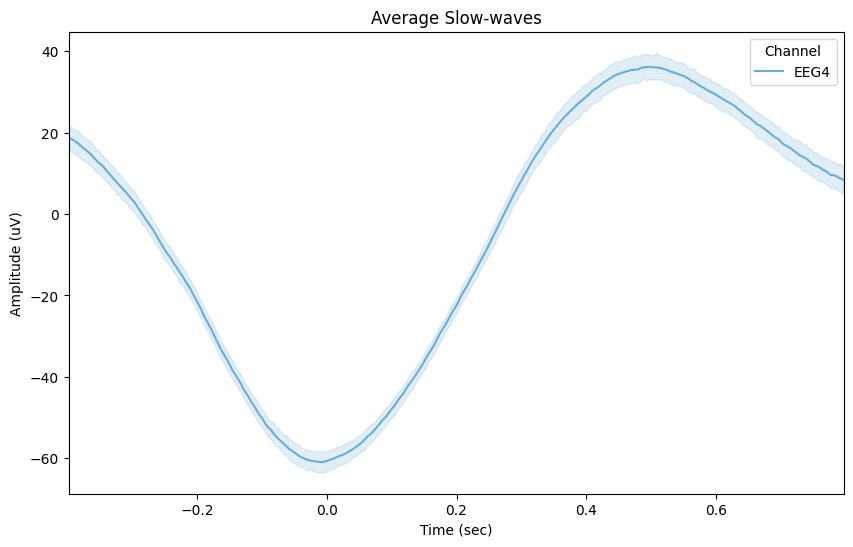

In [178]:
sw.plot_average(ci=99, legend=True, palette='Blues',figsize=(10,6))

plt.title('Average Slow-waves')
plt.show()

## filter out non EEG channels (i.e., Tilt channels) from the SW detection.
##something appears off with the two higher bands (compared to the lower one that is more align with the expected frequency of the YASA demo documentation)

# Automatic Sleep Staging

# Roadblock #6 Vetting automatic sleep staging

**Explained:** Below is what the automatic sleep staging in YASA looks like. The issue here is that I'm supposed to call one of the four EEG channels to get the automatic staging but I'm not sure which to use or if I should do this on all four or what...

EEG channel 1 has the lowest agreement against SleepProfiler's autostaged hypnogram data compared to the other three channel (which seem close in agreement) but, again, I'm still unsure of the nuance among these four channels. TBD

In [179]:
import yasa
from sklearn.metrics import cohen_kappa_score
import pandas as pd

#  "ground-truth" hypnogram (built earlier from primaryautostage / stage_final)
# 'hyp' should already exist as a yasa.Hypnogram object from your earlier mapping step
ground_truth_int = hyp.as_int().to_numpy()

results = []

# for ch in ["EEG1", "EEG2", "EEG3", "EEG4"]:
for ch in ["EEG4"]:
    print(f"Running SleepStaging on {ch}...")
    
    sls = yasa.SleepStaging(raw, eeg_name=ch)
    hypno_pred = sls.predict()  # yasa.Hypnogram object
    
    pred_int = hypno_pred.as_int().to_numpy()
    
    # Align lengths in case of any epoch-count mismatch
    n = min(len(ground_truth_int), len(pred_int))
    
    kappa = cohen_kappa_score(ground_truth_int[:n], pred_int[:n])
    pct_agree = (ground_truth_int[:n] == pred_int[:n]).mean() * 100
    
    results.append({
        "channel": ch,
        "kappa": kappa,
        "pct_agreement": pct_agree,
    })

comparison_df = pd.DataFrame(results).sort_values("kappa", ascending=False)
print(comparison_df)

Running SleepStaging on EEG4...
  channel     kappa  pct_agreement
0    EEG4  0.665642      76.195773


/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


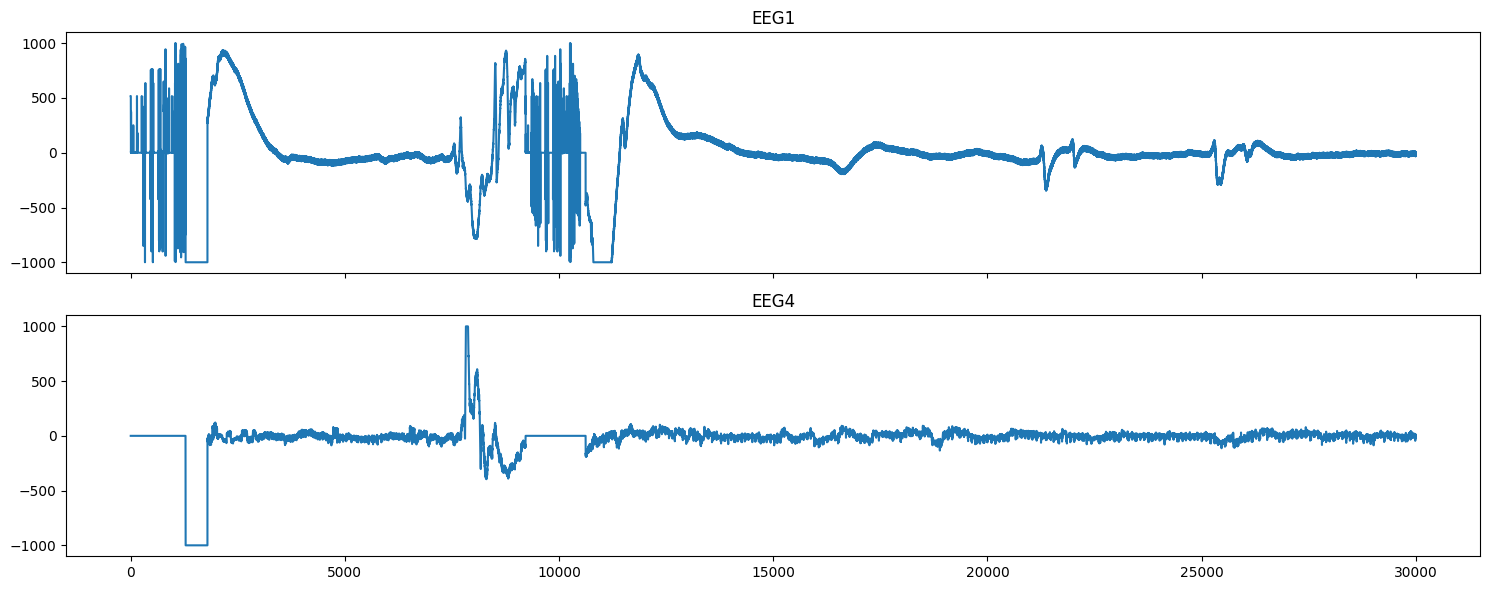

EEG1 - std: 47.88135999413831 | min/max: -1000.0 999.9999999999998
EEG4 - std: 23.543624555080825 | min/max: -1000.0 999.9999999999998


In [180]:
import matplotlib.pyplot as plt

# Visually inspect EEG1 vs a "good" channel side by side
data_eeg1 = raw.get_data(picks='EEG1')[0] * 1e6
data_eeg4 = raw.get_data(picks='EEG4')[0] * 1e6

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
axes[0].plot(data_eeg1[:30000])  # first ~2 min at typical 250Hz
axes[0].set_title("EEG1")
axes[1].plot(data_eeg4[:30000])
axes[1].set_title("EEG4")
plt.tight_layout()
plt.show()

# Quick numeric diagnostics
print("EEG1 - std:", data_eeg1.std(), "| min/max:", data_eeg1.min(), data_eeg1.max())
print("EEG4 - std:", data_eeg4.std(), "| min/max:", data_eeg4.min(), data_eeg4.max())

In [159]:
sls_eeg1 = yasa.SleepStaging(raw, eeg_name="EEG1")
pred_eeg1 = sls_eeg1.predict()
print(pred_eeg1.hypno.value_counts())

YASA
N2      423
N1      313
WAKE     91
REM      72
N3        1
ART       0
UNS       0
Name: count, dtype: int64


/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [160]:
### Are there actually 4 electrodes (EEG1 through EEG4) in the X8 profiler system? Or is this something to do with how the device approximates sleep stages and brain waveforms?

In [161]:
sls_eeg1 = yasa.SleepStaging(raw, eeg_name="EEG1")
pred_eeg1 = sls_eeg1.predict()
print(pred_eeg1.hypno.value_counts())

YASA
N2      423
N1      313
WAKE     91
REM      72
N3        1
ART       0
UNS       0
Name: count, dtype: int64


/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [162]:
sls_eeg2 = yasa.SleepStaging(raw, eeg_name="EEG2")
pred_eeg2 = sls_eeg2.predict()
print(pred_eeg2.hypno.value_counts())

YASA
N2      405
REM     216
N3      179
WAKE     75
N1       25
ART       0
UNS       0
Name: count, dtype: int64


/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [163]:
sls_eeg3 = yasa.SleepStaging(raw, eeg_name="EEG3")
pred_eeg3 = sls_eeg3.predict()
print(pred_eeg3.hypno.value_counts())

YASA
N2      385
REM     236
N3      175
WAKE     92
N1       12
ART       0
UNS       0
Name: count, dtype: int64


/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [164]:
sls_eeg4 = yasa.SleepStaging(raw, eeg_name="EEG4")
pred_eeg4 = sls_eeg4.predict()
print(pred_eeg4.hypno.value_counts())

YASA
N2      380
REM     245
N3      197
WAKE     60
N1       18
ART       0
UNS       0
Name: count, dtype: int64


/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [165]:
sls_eeg4 = yasa.SleepStaging(raw, eeg_name="EEG4")
pred_eeg4 = sls_eeg4.predict()
pred_eeg4.proba.round(2)

/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,WAKE,N1,N2,N3,REM
Epoch,,,,,
0,1.00,0.00,0.00,0.0,0.00
1,1.00,0.00,0.00,0.0,0.00
2,1.00,0.00,0.00,0.0,0.00
3,1.00,0.00,0.00,0.0,0.00
4,1.00,0.00,0.00,0.0,0.00
...,...,...,...,...,...
895,0.27,0.14,0.02,0.0,0.57
896,0.87,0.02,0.01,0.0,0.10
897,0.88,0.06,0.00,0.0,0.06


<Axes: xlabel='Time (30-sec epoch)', ylabel='Probability'>

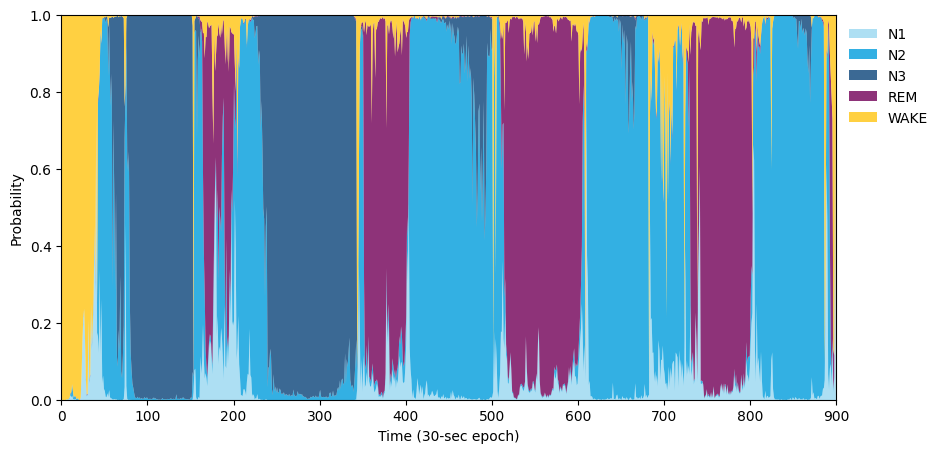

In [166]:
sls_eeg4.plot_predict_proba()

# plt.show()